# Pengantar

Customer (pelanggan) dalam perusahaan berperan sebagai salah satu sumber pendapatan utama dan faktor keberhasilan perusahaan. Perlu dicari tahu apa saja hal-hal yang berpotensi mengakibatkan customer berhenti berlangganan (customer churn).

Berikut merupakan machine learning modeling dari dataset **Telecom Customer Churn** yang berfokus pada *customer retention programs*.

Metrics: Recall dan ROC AUC

Target:
- Menganalisa apa saja yang mempengaruhi pelanggan untuk tetap bertahan atau berhenti
- Membangun ML model untuk memprediksi apakah pelanggan akan berhenti berlangganan atau tidak

In [1]:
# Import libraries here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Data Pipeline

In [2]:
# create a function to import dataset and drop duplicates

def importData(filename):

  """
  a function to import dataset and drop duplicates
  :dataset filename: csv file
  :return: dataframe
  """

  # read data
  df = pd.read_csv(filename)
  print("Raw data contain             : ", df.shape, "- (#observation, #column)")

  # drop duplicates
  df = df.drop_duplicates()
  print("Drop duplicates data contain : ", df.shape, "- (#observation, #column)")

  return df

In [3]:
# input
file_telecom = "https://github.com/YBIFoundation/Dataset/raw/main/TelecomCustomerChurn.csv"

# import dataset
telecom_df = importData(filename = file_telecom)

Raw data contain             :  (7043, 21) - (#observation, #column)
Drop duplicates data contain :  (7043, 21) - (#observation, #column)


In [4]:
telecom_df.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


## Data validation

In [5]:
telecom_raw = telecom_df.copy()

In [6]:
telecom_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Berdasarkan pengecekan di atas, diperoleh bahwa terdapat ketidaksesuaian antara type data, data yang disajikan, dan definisi dari setiap feature-nya.

In [7]:
# create a function to see value counts for each features

def dtypesCheck(data, features):
  """
  Checking value counts for each data types
  :data: dataframe
  :features: list
  """
  for i in range(len(features)):
    print("Value Counts for   : ", features[i])
    print(data[features[i]].value_counts())
    print("")

In [8]:
# data types = object
telecom_object = telecom_raw.select_dtypes(include="object").columns.to_list()
dtypesCheck(data = telecom_raw, features = telecom_object)

Value Counts for   :  customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

Value Counts for   :  Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Value Counts for   :  Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Value Counts for   :  Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Value Counts for   :  PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Value Counts for   :  MultipleLines
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

Value Counts for   :  InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Value Counts for   :  OnlineSecurity
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64

Value Counts for  

In [9]:
# data types = int64
telecom_integer = telecom_raw.select_dtypes(include="int64").columns.to_list()
dtypesCheck(data = telecom_raw, features = telecom_integer)

Value Counts for   :  SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Value Counts for   :  Tenure
Tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64



In [10]:
# data types = float64
telecom_float = telecom_raw.select_dtypes(include="float64").columns.to_list()
dtypesCheck(data = telecom_raw, features = telecom_float)

Value Counts for   :  MonthlyCharges
MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
56.85      1
101.70     1
48.40      1
108.35     1
72.00      1
Name: count, Length: 1585, dtype: int64



Dari hasil di atas, features yang sudah sesuai dengan data definition:
- Primary Key: customerID (string) akan didrop
- Nominal (binary): SeniorCitizen
- Integer: Tenure
- Float: MonthlyCharges

Features yang perlu disesuaikan pada proses data preprocessing/feature engineering:
- Nominal (binary): Label Encoding  into (1, 0) <br> Gender, Partner, Dependents, PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling, Churn.
- String: One Hot Encoding <br> InternetService, Contract, PaymentMethod.
- Float: <br> TotalCharges

### Object into boolean (1, 0)

In [11]:
into_boolean = ["Partner", "Dependents", "PhoneService", "MultipleLines",
                "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
                "StreamingTV", "StreamingMovies", "PaperlessBilling", "Churn"]

for i in into_boolean:
  telecom_raw[i] = telecom_raw[i].replace({"Yes": 1, "No": 0})

<ipython-input-11-992662d6ab69>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telecom_raw[i] = telecom_raw[i].replace({"Yes": 1, "No": 0})


### Object into float

In [12]:
telecom_raw.TotalCharges = telecom_raw.TotalCharges.replace(" ", np.nan)

In [13]:
telecom_raw.TotalCharges = telecom_raw.TotalCharges.astype(float)

In [14]:
telecom_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   int64  


### Drop customerID

In [15]:
telecom_raw = telecom_raw.drop(columns = "customerID").copy()
telecom_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   Tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


## Data splitting

### Split input output

In [16]:
# create function to split features and target

def splitInputOutput(data, target_col):
  X = data.drop(columns = target_col)
  y = data[target_col]
  return X, y

In [17]:
# split features and target
X, y = splitInputOutput(data = telecom_raw,
                        target_col = "Churn")

# features dataset
X.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Monthly,1,Manual,29.85,29.85
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Manual,56.95,1889.50
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Monthly,1,Manual,53.85,108.15
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Monthly,1,Manual,70.70,151.65


In [18]:
# target dataset
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [19]:
# cek proporsi target
y.value_counts(normalize = True)

,proportion
Churn,
0,0.73463
1,0.26537


proporsi target tidak balance.

### Split train valid test

In [20]:
# import library
from sklearn.model_selection import train_test_split

In [21]:
# Split dataset menjadi data train, data validasi, dan data test
# data train: X_train, y_train
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 42,
                                                    stratify = y)
# data valid, data test
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test,
                                                    test_size = 0.5,
                                                    random_state = 42,
                                                    stratify = y_test)

X_train.shape, X_valid.shape, X_test.shape

((4930, 19), (1056, 19), (1057, 19))

In [22]:
# Check hasil splitting
print(f"Jumlah label data asli:\n{y.value_counts()}")
print(f"Jumlah label data train:\n{y_train.value_counts()}")
print(f"Jumlah label data validasi:\n{y_valid.value_counts()}")
print(f"Jumlah label data test:\n{y_test.value_counts()}")

Jumlah label data asli:
Churn
0    5174
1    1869
Name: count, dtype: int64
Jumlah label data train:
Churn
0    3622
1    1308
Name: count, dtype: int64
Jumlah label data validasi:
Churn
0    776
1    280
Name: count, dtype: int64
Jumlah label data test:
Churn
0    776
1    281
Name: count, dtype: int64


# Exploratory Data Analysis

Akan dilakukan eksplorasi dari data train.

In [23]:
telecom_eda = pd.concat([X_train, y_train], axis = 1)

## Missing value

In [24]:
# cek null value
telecom_eda.isnull().sum()

,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Seputar features data:
- Terdapat null value pada feature TotalCharges.
- Periksa distribusi feature untuk mengetahui metode imputasi yang lebih baik.

## Duplicate value

In [25]:
telecom_eda.duplicated().sum()

np.int64(13)

Seputar features data:
- Terdapat duplicates row sebanyak 13 baris.
- Delete duplicate keep first.

## Features distribution

In [26]:
telecom_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4930 entries, 5557 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            4930 non-null   object 
 1   SeniorCitizen     4930 non-null   int64  
 2   Partner           4930 non-null   int64  
 3   Dependents        4930 non-null   int64  
 4   Tenure            4930 non-null   int64  
 5   PhoneService      4930 non-null   int64  
 6   MultipleLines     4930 non-null   int64  
 7   InternetService   4930 non-null   object 
 8   OnlineSecurity    4930 non-null   int64  
 9   OnlineBackup      4930 non-null   int64  
 10  DeviceProtection  4930 non-null   int64  
 11  TechSupport       4930 non-null   int64  
 12  StreamingTV       4930 non-null   int64  
 13  StreamingMovies   4930 non-null   int64  
 14  Contract          4930 non-null   object 
 15  PaperlessBilling  4930 non-null   int64  
 16  PaymentMethod     4930 non-null   object 
 1

In [27]:
# numerical features
numerical_features = ["Tenure", "MonthlyCharges", "TotalCharges"]

# categorical features
cat_customer_related = ["Gender", "SeniorCitizen", "Partner", "Dependents"]
cat_service_related = ["PhoneService", "MultipleLines", "InternetService",
                       "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                       "TechSupport", "StreamingTV", "StreamingMovies"]
cat_package_related = ["PaperlessBilling", "Contract", "PaymentMethod"] # (& Tenure)

# categorical features
boolean_features = ["SeniorCitizen", "Partner", "Dependents",
                    "PhoneService", "MultipleLines", "OnlineSecurity",
                    "OnlineBackup", "DeviceProtection", "TechSupport",
                    "StreamingTV", "StreamingMovies", "PaperlessBilling"]
nominal_features = ["Gender", "InternetService", "Contract", "PaymentMethod"]

# target
target = ["Churn"]

### target: Churn

In [28]:
telecom_eda[target].value_counts(normalize = True)

,proportion
Churn,
0,0.734686
1,0.265314


Insight:
- Sebanyak 26.53% customer memutuskan untuk berhenti berlangganan.

### numerical features

In [29]:
# numerical features summary
telecom_eda[numerical_features].describe()

,Tenure,MonthlyCharges,TotalCharges
count,4930.000000,4930.000000,4923.000000
mean,32.471197,64.950081,2305.070485
std,24.646350,30.243674,2292.550954
min,0.000000,18.400000,18.850000
25%,9.000000,35.500000,399.800000
50%,29.000000,70.575000,1389.200000
75%,56.000000,90.050000,3860.300000
max,72.000000,118.750000,8684.800000


In [30]:
# akan diamati perbedaan nilai statistik berdasarkan kelas
telecom_eda_churn = telecom_eda[telecom_eda.Churn == 1].copy()
telecom_eda_no_churn = telecom_eda[telecom_eda.Churn == 0].copy()

In [31]:
# kelas Churn = 1
telecom_eda_churn[numerical_features].describe()

,Tenure,MonthlyCharges,TotalCharges
count,1308.000000,1308.00000,1308.000000
mean,18.383792,75.00130,1576.223700
std,20.002627,24.56971,1943.484725
min,1.000000,18.85000,18.850000
25%,2.000000,56.25000,138.750000
50%,10.000000,80.00000,705.075000
75%,30.000000,94.46250,2376.937500
max,72.000000,118.35000,8684.800000


In [32]:
# kelas Churn = 0
telecom_eda_no_churn[numerical_features].describe()

,Tenure,MonthlyCharges,TotalCharges
count,3622.000000,3622.000000,3615.000000
mean,37.558531,61.320320,2568.786003
std,24.184159,31.265296,2351.631921
min,0.000000,18.400000,18.900000
25%,15.000000,25.100000,567.150000
50%,38.000000,64.450000,1679.400000
75%,61.000000,88.537500,4266.775000
max,72.000000,118.750000,8672.450000


In [33]:
# skewness
telecom_eda[numerical_features].skew()

,0
Tenure,0.240294
MonthlyCharges,-0.219792
TotalCharges,0.948922


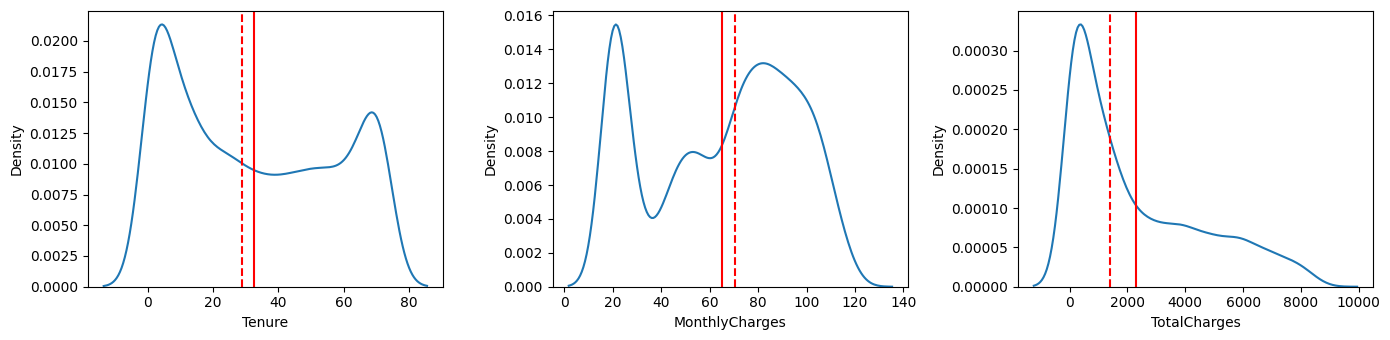

In [34]:
# feature distribution
rcParams["figure.figsize"] = 14, 3.5
for i in numerical_features:
  # subplot
  plt.subplot(1, 3, numerical_features.index(i) + 1)
  # distribution
  sns.kdeplot(data = telecom_eda, x = i)
  plt.axvline(x = telecom_eda[i].mean(), color = "red", label = "mean")
  plt.axvline(x = telecom_eda[i].median(), color = "red", linestyle = "dashed", label = "median")
  plt.tight_layout()

Insight:
- TotalCharges positive skew >> nilai total charges customer terkonsentrasi pada rentang 0 - 2000.
- Tenure dan MonthlyCharges memiliki *2 puncak*. **Apa yang menyebabkan distribusi bimodal tersebut?**

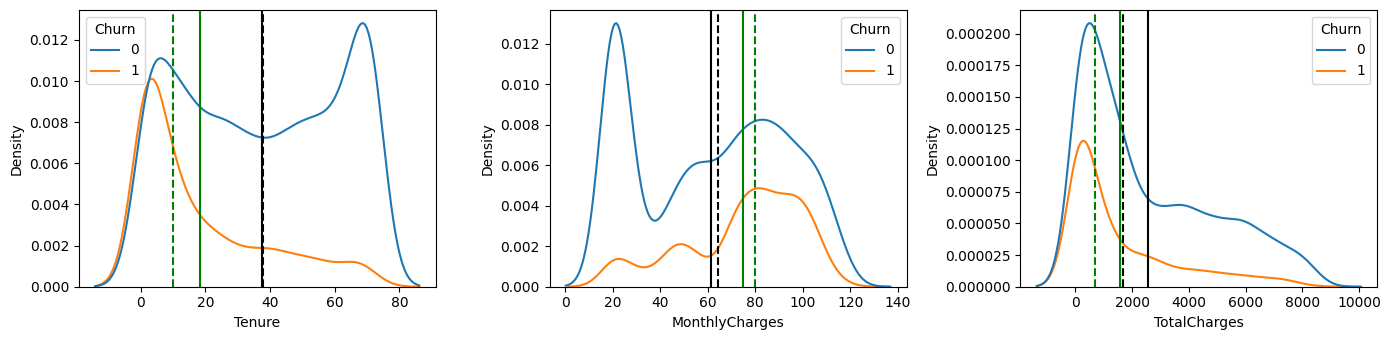

In [35]:
# feature distribution / target churn
rcParams["figure.figsize"] = 14, 3.5
for i in numerical_features:
  # subplot
  plt.subplot(1, 3, numerical_features.index(i) + 1)
  # class distribution
  sns.kdeplot(data = telecom_eda, x = i, hue = "Churn")
  plt.axvline(x = telecom_eda_churn[i].mean(), color = "g")
  plt.axvline(x = telecom_eda_no_churn[i].mean(), color = "k")
  plt.axvline(x = telecom_eda_churn[i].median(), linestyle = "dashed", color = "g")
  plt.axvline(x = telecom_eda_no_churn[i].median(), linestyle = "dashed", color = "k")
  plt.tight_layout()

Insight:
- Churn customer memiliki nilai Tenure yang cenderung terkonsentrasi pada rentang 0-20 bulan (< 1 tahun)(skew positif). \\
  Customer cenderung memutuskan untuk berhenti setelah kurang dari satu tahun berlangganan.
- Churn customer memiliki besaran MonthlyCharges yang terkonsentrasi pada nilai 80-100 (skew negatif). \\
  Customer yang memutuskan untuk berhenti berlangganan lebih banyak terkonsentrasi pada nilai MonthlyCharges yang lebih besar (80-100).
- Distribusi no churn customer pada Tenure dan MonthlyCustomer *bimodal*. \\
  **Bagaimana pengaruh besaran Tenure dan MonthlyCharges pada no churn customer?**

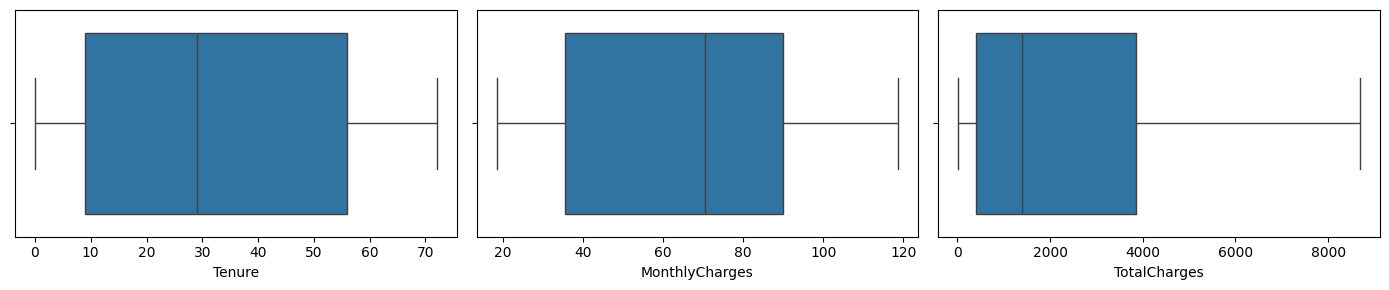

In [36]:
# feature distribution / target churn
rcParams["figure.figsize"] = 14, 3
for i in numerical_features:
  # subplot
  plt.subplot(1, 3, numerical_features.index(i) + 1)
  # boxplot
  sns.boxplot(data = telecom_eda, x = i)
  plt.tight_layout()

Seputar features data:
- Tidak ada outlier pada ketiga boxplot di atas.

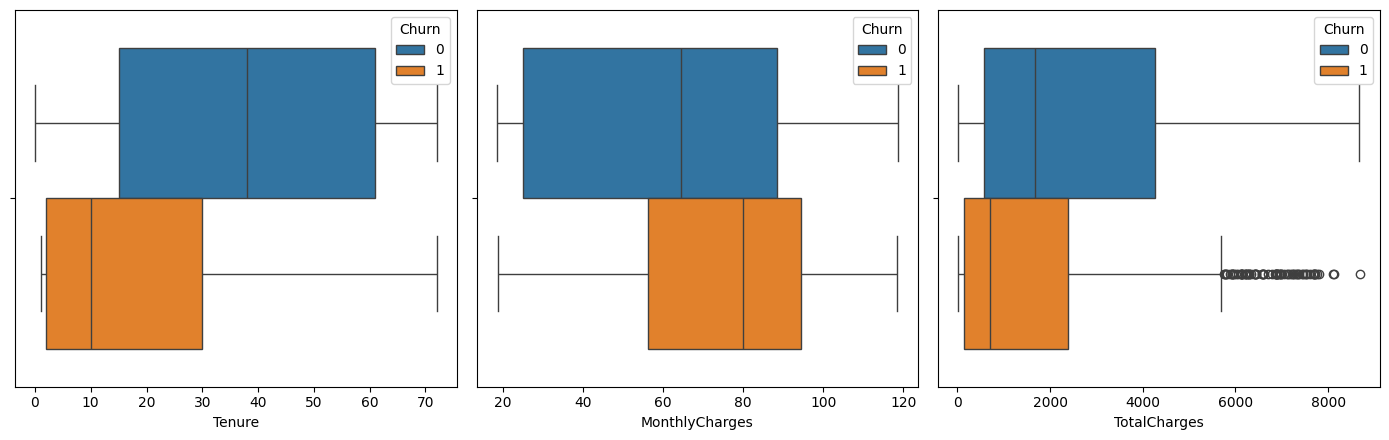

In [37]:
# feature distribution / target churn
rcParams["figure.figsize"] = 14, 4.5
for i in numerical_features:
  # subplot
  plt.subplot(1, 3, numerical_features.index(i) + 1)
  # boxplot based on class
  sns.boxplot(data = telecom_eda, x = i, hue = "Churn")
  plt.tight_layout()

In [38]:
# t-test
import scipy.stats as stats

# H0: mean telecom_eda_churn = mean telecom_eda_no_churn
# H1: mean telecom_eda_churn != mean telecom_eda_no_churn

for i in numerical_features:
  print(i)

  # perform t-test untuk numerical features
  print(stats.ttest_ind(a = telecom_eda_churn[telecom_eda_churn[i].isnull() != True][i],
                        b = telecom_eda_no_churn[telecom_eda_no_churn[i].isnull() != True][i]))

  # nilai t critical untuk alpha = 0.05
  print(stats.t.ppf(0.05, df = len(telecom_eda) - 2))

  print("")

Tenure
TtestResult(statistic=np.float64(-25.677611213135307), pvalue=np.float64(1.4004434837917478e-136), df=np.float64(4928.0))
-1.6451628918416097

MonthlyCharges
TtestResult(statistic=np.float64(14.3098077478804), pvalue=np.float64(1.5369625919713456e-45), df=np.float64(4928.0))
-1.6451628918416097

TotalCharges
TtestResult(statistic=np.float64(-13.668772792871234), pvalue=np.float64(8.962419788290152e-42), df=np.float64(4921.0))
-1.6451628918416097



Seputar features data:

**Imputation of Missing Values**: \\

TotalCharges:
- Standar deviasi sangat besar.
- Distribusi hanya memiliki satu puncak.
- Skew positif 0.95 > 0.50, maka kolom tersebut dapat diimputasi dengan nilai median.
- Tidak diperoleh outlier pada boxplot.
- Berdasarkan t-test hypotesis, t-value < t-critical dan p-value < 0.05, maka H0 ditolak (mean antara kelas Churn dan kelas No Churn untuk TotalCharges statistically significant.
- Imputasi missing values: nilai median kelas. \\

MonthlyCharges dan Tenure:
- Distribusi "bimodal", memiliki dua puncak.
- Uji hipotesis t dilakukan untuk distribusi normal, sehingga hasil uji (utamanya MonthlyCharges dan Tenure) tidak dipertimbangkan.
- Imputasi: mean kelas

### categorical features - customer related

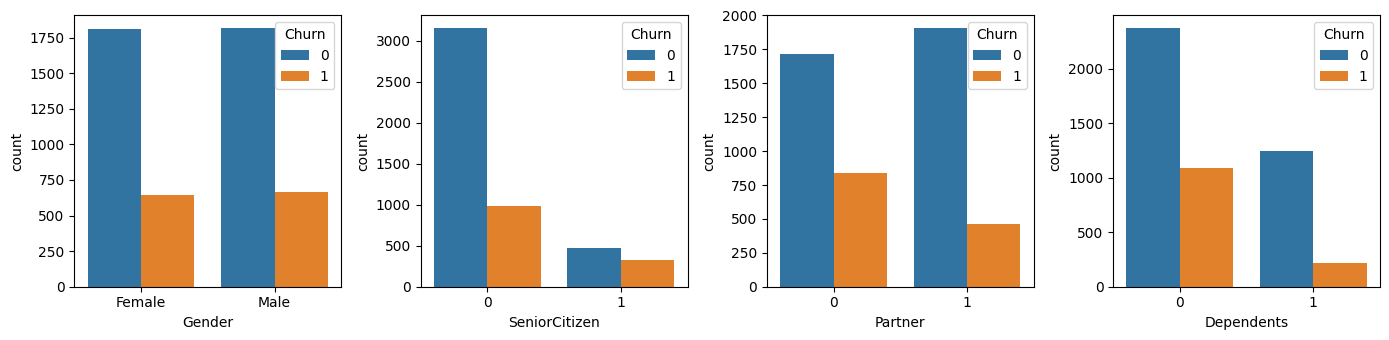

In [39]:
# distribusi categorical customer related
rcParams["figure.figsize"] = 14, 3.5
for i in cat_customer_related:
  # subplot
  plt.subplot(1, 4, cat_customer_related.index(i) + 1)
  # boxplot based on class
  sns.countplot(data = telecom_eda, x = i, hue = "Churn")
  plt.tight_layout()

In [40]:
# distribution for categorical features (customer related)

rcParams["figure.figsize"] = 14, 3.5
for i in cat_customer_related:
  customer_related = telecom_eda.groupby(i)
  # percentage
  percentage = customer_related["Churn"].value_counts(normalize = True).reset_index(name = "Percentage")
  print(percentage)
  print("")

   Gender  Churn  Percentage
0  Female      0    0.736949
1  Female      1    0.263051
2    Male      0    0.732446
3    Male      1    0.267554

   SeniorCitizen  Churn  Percentage
0              0      0    0.762573
1              0      1    0.237427
2              1      0    0.589421
3              1      1    0.410579

   Partner  Churn  Percentage
0        0      0    0.670837
1        0      1    0.329163
2        1      0    0.803541
3        1      1    0.196459

   Dependents  Churn  Percentage
0           0      0    0.685244
1           0      1    0.314756
2           1      0    0.851397
3           1      1    0.148603



Insight: \\
Persentase conversion rate dari customer yang memutuskan untuk berhenti berlangganan:
- 41.06% dari SeniorCitizen customer memutuskan untuk berhenti berlangganan.
- 32.92% dari customer yang tidak memiliki Partner memutuskan untuk berhenti berlangganan.
- 31.48% dari customer yang tidak memiliki Dependents memutuskan untuk berhenti berlangganan.

di mana, persentase di atas lebih besar dari persentase customer churn keseluruhan (26%). Kelompok tersebut di atas dapat ditandai sebagai kelompok customer yang memiliki potensi untuk berhenti berlangganan yang tinggi.

Namun perlu diperhatikan juga bahwa jumlah customer dari kelompok non SeniorCitizen cukup banyak yang memutuskan untuk berhenti berlangganan.


In [41]:
# distribution for categorical features
churn_gender = telecom_eda.groupby(["Gender", "Churn"])
for i in cat_customer_related[1:]:
  # percentage
  percentage = churn_gender[i].value_counts(normalize = True).reset_index(name = "Percentage")
  print(percentage)
  print("")

   Gender  Churn  SeniorCitizen  Percentage
0  Female      0              0    0.875484
1  Female      0              1    0.124516
2  Female      1              0    0.762791
3  Female      1              1    0.237209
4    Male      0              0    0.866116
5    Male      0              1    0.133884
6    Male      1              0    0.739065
7    Male      1              1    0.260935

   Gender  Churn  Partner  Percentage
0  Female      0        1    0.539568
1  Female      0        0    0.460432
2  Female      1        0    0.658915
3  Female      1        1    0.341085
4    Male      0        1    0.512948
5    Male      0        0    0.487052
6    Male      1        0    0.628959
7    Male      1        1    0.371041

   Gender  Churn  Dependents  Percentage
0  Female      0           0    0.664084
1  Female      0           1    0.335916
2  Female      1           0    0.832558
3  Female      1           1    0.167442
4    Male      0           0    0.646281
5    Male     

Insight: \\
Wanita yang memutuskan untuk berhenti berlangganan:
- 76.28% merupakan non-SeniorCitizen
- 65.89% tidak mempunyai Partner
- 83.26% tidak memiliki Dependents

Pria yang memutuskan untuk berhenti berlangganan:
- 73.91% merupakan non-SeniorCitizen
- 62.90% tidak mempunyai Partner
- 83.41% tidak memiliki Dependents

Berdasarkan data di atas, diperoleh bahwa:
- "Karakteristik" Wanita dan Pria yang memutuskan untuk berhenti berlangganan "cukup mirip".
- Features dapat dipertimbangkan untuk didrop pada feature selection.

### categorical features - service related

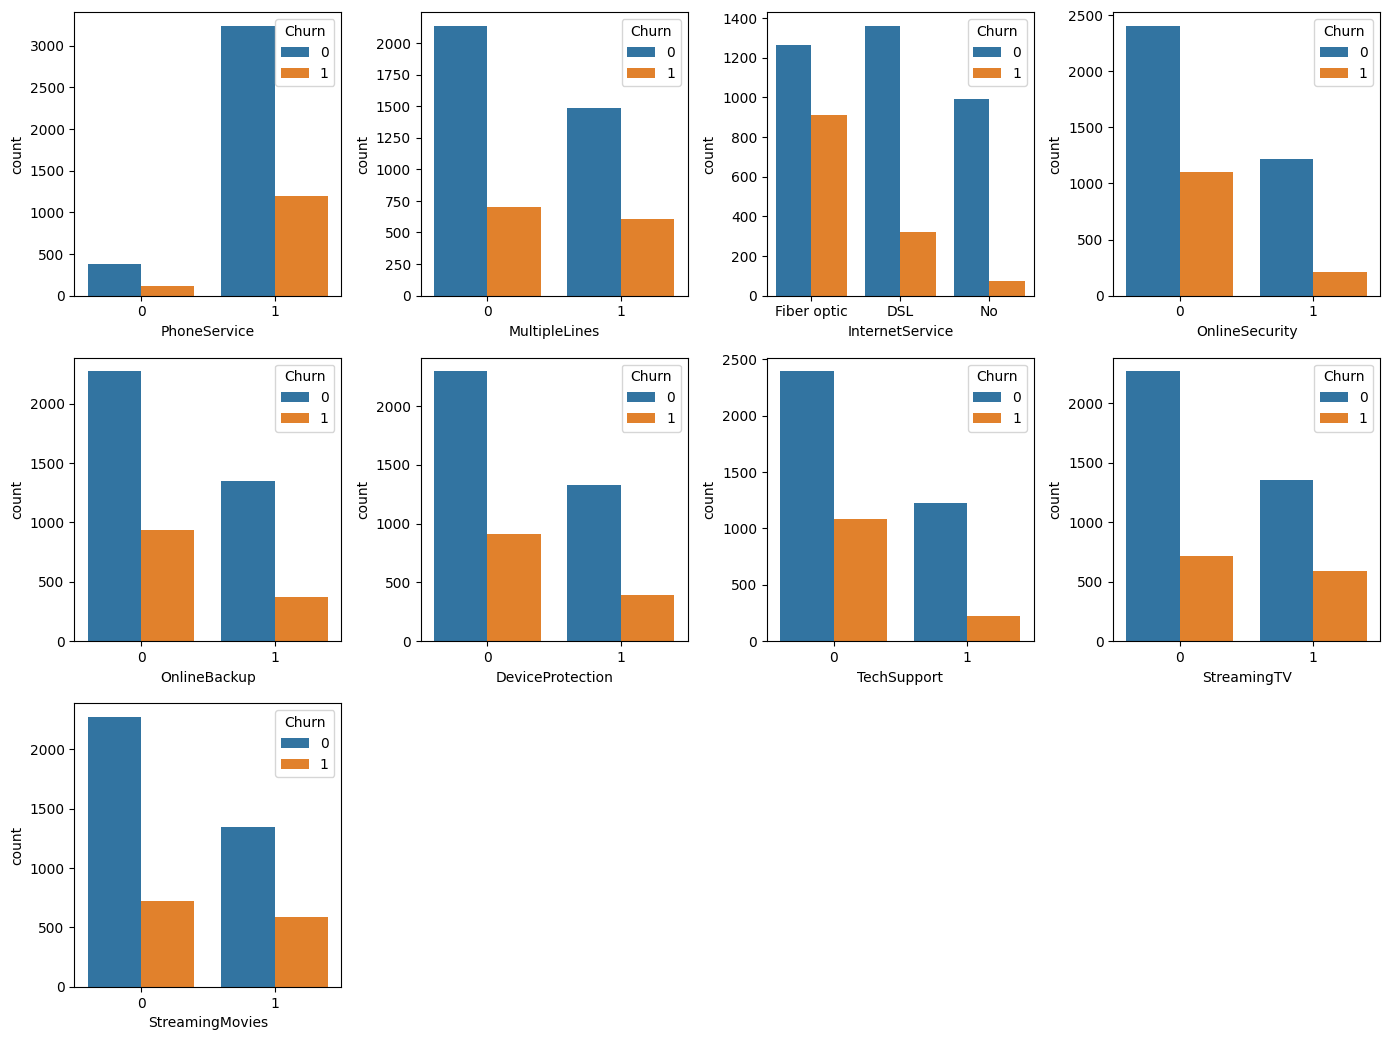

In [42]:
# distribusi categorical service related
rcParams["figure.figsize"] = 14, 3.5*3
for i in cat_service_related:
  # subplot
  plt.subplot(3, 4, cat_service_related.index(i) + 1)
  # boxplot based on class
  sns.countplot(data = telecom_eda, x = i, hue = "Churn")
  plt.tight_layout()

In [43]:
# distribution for categorical features
for i in cat_service_related:
  service_related = telecom_eda.groupby(i)
  # percentage
  percentage = service_related["Churn"].value_counts(normalize = True).reset_index(name = "Percentage")
  print(percentage)
  print("")

   PhoneService  Churn  Percentage
0             0      0    0.766129
1             0      1    0.233871
2             1      0    0.731168
3             1      1    0.268832

   MultipleLines  Churn  Percentage
0              0      0    0.752374
1              0      1    0.247626
2              1      0    0.710589
3              1      1    0.289411

  InternetService  Churn  Percentage
0             DSL      0    0.808309
1             DSL      1    0.191691
2     Fiber optic      0    0.581534
3     Fiber optic      1    0.418466
4              No      0    0.930712
5              No      1    0.069288

   OnlineSecurity  Churn  Percentage
0               0      0    0.686627
1               0      1    0.313373
2               1      0    0.853127
3               1      1    0.146873

   OnlineBackup  Churn  Percentage
0             0      0    0.708100
1             0      1    0.291900
2             1      0    0.784302
3             1      1    0.215698

   DeviceProtection  

Insight: \\
Persentase conversion rate dari customer yang berakhir memutuskan berhenti berlangganan:
- 41.85% dari customer yang menggunakan InternetService Fiber optic memutuskan untuk berhenti berlangganan.
- 31.34% customer yang tidak menggunakan OnlineSecurity memutuskan untuk berhenti berlangganan.
- 31.19% customer yang tidak menggunakan TechSupport memutuskan untuk berhenti berlangganan.
- 30.35% customer yang menggunakan layanan StreamingTV memutuskan untuk berhenti berlangganan.
- 30.24% customer yang menggunakan layanan StreamingMovies memutuskan untuk berhenti berlangganan.

### categorical features - package related

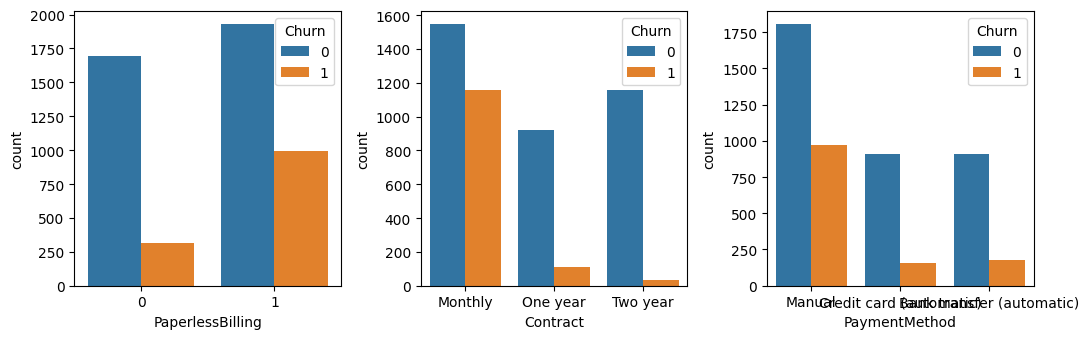

In [44]:
# distribusi categorical package related
rcParams["figure.figsize"] = 14, 3.5
for i in cat_package_related:
  # subplot
  plt.subplot(1, 4, cat_package_related.index(i) + 1)
  # boxplot based on class
  sns.countplot(data = telecom_eda, x = i, hue = "Churn")
  plt.tight_layout()

In [45]:
# distribution for categorical features
for i in cat_package_related:
  package_related = telecom_eda.groupby(i)
  # percentage
  percentage = package_related["Churn"].value_counts(normalize = True).reset_index(name = "Percentage")
  print(percentage)
  print("")

   PaperlessBilling  Churn  Percentage
0                 0      0    0.843284
1                 0      1    0.156716
2                 1      0    0.659932
3                 1      1    0.340068

   Contract  Churn  Percentage
0   Monthly      0    0.571376
1   Monthly      1    0.428624
2  One year      0    0.890716
3  One year      1    0.109284
4  Two year      0    0.969799
5  Two year      1    0.030201

               PaymentMethod  Churn  Percentage
0  Bank transfer (automatic)      0    0.837017
1  Bank transfer (automatic)      1    0.162983
2    Credit card (automatic)      0    0.852858
3    Credit card (automatic)      1    0.147142
4                     Manual      0    0.649262
5                     Manual      1    0.350738



Insight: \\
Persentase conversion rate dari customer yang berakhir memutuskan berhenti berlangganan:
- 42.86% customer yang menggunakan paket Contract Monthly memutuskan untuk berhenti berlangganan.
- 35.07% customer yang menggunakan PaymentMethod Manual memutuskan untuk berhenti berlangganan.
- 34.01% customer yang menggunakan PaperlessBilling memutuskan untuk berhenti berlangganan.

### summary bagian satu

Seputar features data: \\

***Data Preprocessing: Imputation***
- categorical (nominal):
  - Gender: Modus
  - Lainnya: Modus kelas
- numerik:
  - Tenure: Mean kelas
  - MonthlyCharges: Mean kelas
  - TotalCharges: Median kelas

Insight:

**Customer churn**
- Customer memutuskan berhenti berlangganan kurang dari satu tahun masa berlangganan (nilai Tenure < 20).
- Customer yang memutuskan untuk berhenti berlangganan cenderung memiliki nilai MonthlyCharges yang lebih besar.

**Customer seperti apa yang memiliki potensi lebih besar untuk berhenti berlangganan?**
- 42.86% customer yang menggunakan paket **Contract Monthly** memutuskan untuk berhenti berlangganan --vs (10% One year, 3% Two year; diff 30%)
- 41.85% pengguna layanan **InternetService Fiber optic** memutuskan untuk berhenti berlangganan --vs (11% DSL; diff 30%)
- 41.06% SeniorCitizen memutuskan untuk berhenti berlangganan --vs (No 24%; diff 17%)
- 35.07% customer yang menggunakan **PaymentMethod Manual** memutuskan untuk berhenti berlangganan --vs (Others 15%; diff 20%)
- 34.01% customer yang menggunakan PaperlessBilling memutuskan untuk berhenti berlangganan --vs (No 16%; diff 18%)
- 33% customer yang tidak memiliki Partner memutuskan untuk berhenti berlangganan --vs (Yes 20%; diff 13%)
- 31% customer yang tidak memiliki Dependents memutuskan untuk berhenti berlangganan --vs (Yes 15%; diff 16%)
- 31.34% customer yang tidak menggunakan layanan OnlineSecurity memutuskan untuk berhenti berlangganan --vs (Yes 15%; diff 16%)
- 31.19% customer yang tidak menggunakan layanan TechSupport memutuskan untuk berhenti berlangganan --vs (Yes 15%; diff 16%)
- 30% customer yang menggunakan layanan StreamingTV dan StreamingMovies memutuskan untuk berhenti berlangganan --vs (No 24%; diff 6%)



## Features - churn analysis

### korelasi numerical features dan churn

<Axes: >

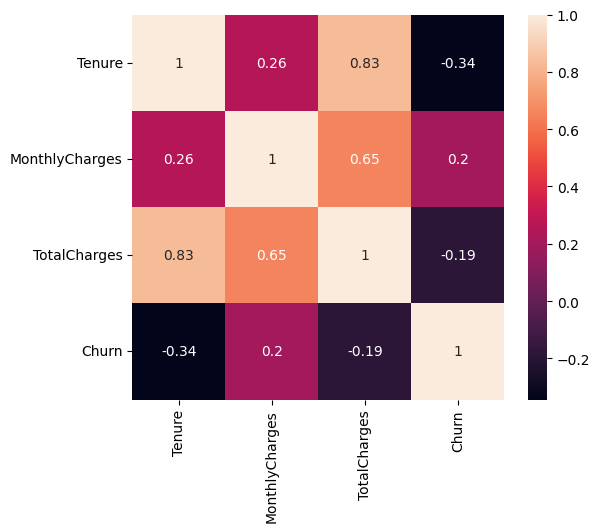

In [46]:
# pearson correlation for numerical coefficient and target Churn
rcParams["figure.figsize"] = 6, 5
sns.heatmap(telecom_eda[numerical_features + ['Churn']].corr(), annot = True)

In [47]:
# point-biserial correlation between binary and continuous features

# function for calculate correlation
def CorrPointBiserial (x, y):
  corr, p = stats.pointbiserialr(x, y)
  return corr, p

In [48]:
# point-biserial correlation with Churn

# delete/imputation null values for calculate correlation
telecom_eda_pbc = telecom_eda.dropna().copy()

for i in numerical_features:
  print(i, "dan Churn")
  print(CorrPointBiserial(telecom_eda_pbc["Churn"], telecom_eda_pbc[i]))
  print("")

Tenure dan Churn
(np.float64(-0.34516072153582755), np.float64(9.237737749032401e-138))

MonthlyCharges dan Churn
(np.float64(0.19924135309863922), np.float64(2.950259128677523e-45))

TotalCharges dan Churn
(np.float64(-0.19125424346878425), np.float64(8.962419788289271e-42))



Nilai koefisien korelasi point-biseral antara numerical features dan Churn cukup rendah. Tenure dan TotalCharges memiliki hubungan negatif (lemah), sementara MonthlyCharges positif (lemah). \\

Nilai p-value yang diperoleh mendekati nol (< 0.05), dapat dipertimbangkan bahwa ketiga numerical features statistically significant terhadap Churn.

### korelasi nominal features dan churn

In [49]:
# chi-squared hypotesis

# hypotesis define
# H0: there is no significant relationship between the two variables
# H1: there is a significant relationship between the two variables

# function to calculate chi2
def Chi2Calculated(x, y):

  # create table dataset for two features
  cross_tab = pd.crosstab(x, y)

  # calculate chi-squared
  chi2, p, dof, expected = stats.chi2_contingency(cross_tab)
  return chi2, p, dof, expected

In [50]:
# chi-square test

for i in nominal_features:
  print(i, "dan Churn")
  result_chi = Chi2Calculated(telecom_eda_pbc[i], telecom_eda_pbc["Churn"])
  print(result_chi)

  # p-value checking
  if result_chi[1] < 0.05:
    print("H0 ditolak, dependent")
  else:
    print("H0 diterima, independent")

  print("")

Gender dan Churn
(np.float64(0.11169979515597017), np.float64(0.7382171802586434), 1, array([[1798.32114564,  650.67885436],
       [1816.67885436,  657.32114564]]))
H0 diterima, independent

InternetService dan Churn
(np.float64(517.023180847558), np.float64(5.368374081462992e-113), 2, array([[1235.10664229,  446.89335771],
       [1598.58927483,  578.41072517],
       [ 781.30408288,  282.69591712]]))
H0 ditolak, dependent

Contract dan Churn
(np.float64(833.9004282941837), np.float64(8.33341034722551e-182), 2, array([[1985.56977453,  718.43022547],
       [ 759.27483242,  274.72516758],
       [ 870.15539305,  314.84460695]]))
H0 ditolak, dependent

PaymentMethod dan Churn
(np.float64(239.43175471951747), np.float64(1.0187205487286415e-52), 2, array([[ 795.99024985,  288.00975015],
       [ 783.50700792,  283.49299208],
       [2035.50274223,  736.49725777]]))
H0 ditolak, dependent



Berdasarkan uji hipotesis di atas, diperoleh bahwa Gender tidak berpengaruh secara signifikan terhadap Churn, sementara feature kategorikal lainnya berpengaruh secara signifikan.

### korelasi boolean features dan churn

In [51]:
# chi-square test for nominal (dichotom features)
for i in boolean_features:
  print(i, "dan Churn")
  result_chi = Chi2Calculated(telecom_eda_pbc[i], telecom_eda_pbc["Churn"])
  print(result_chi)

  # p-value checking
  if result_chi[1] < 0.05:
    print("H0 ditolak, dependent")
  else:
    print("H0 diterima, independent")

  print("")

SeniorCitizen dan Churn
(np.float64(100.97845432439655), np.float64(9.298945513935944e-24), 1, array([[3031.95917124, 1097.04082876],
       [ 583.04082876,  210.95917124]]))
H0 ditolak, dependent

Partner dan Churn
(np.float64(109.63159319003361), np.float64(1.180047072456576e-25), 1, array([[1877.62644729,  679.37355271],
       [1737.37355271,  628.62644729]]))
H0 ditolak, dependent

Dependents dan Churn
(np.float64(143.23370659274025), np.float64(5.225554285944266e-33), 1, array([[2542.90981109,  920.09018891],
       [1072.09018891,  387.90981109]]))
H0 ditolak, dependent

PhoneService dan Churn
(np.float64(2.5962604990174007), np.float64(0.10711618894795681), 1, array([[ 363.48263254,  131.51736746],
       [3251.51736746, 1176.48263254]]))
H0 diterima, independent

MultipleLines dan Churn
(np.float64(10.69108976078692), np.float64(0.0010765277251536334), 1, array([[2085.43570993,  754.56429007],
       [1529.56429007,  553.43570993]]))
H0 ditolak, dependent

OnlineSecurity dan C

Berdasarkan uji hipotesis di atas, feature PhoneService tidak berpengaruh secara signifikan terhadap Churn, sementara yang lain berpengaruh signifikan.

### summary bagian dua

***Exploration***
- Features yang "berpengaruh secara signifikan" terhadap Churn:
  - Tenure (negative corr, low)
  - TotalCharges (negative corr, low)
  - MonthlyCharges (positive corr, low)
  - InternetService
  - Contract
  - PaymentMethod
  - Others (dichotom features)

- Feature yang "tidak berpengaruh secara signifikan" terhadap Churn:
  - Gender (uji hipotesis chi-2)
  - PhoneService

- Imbalance kelas Churn dan No Churn

***Data Preprocessing*** \\
- Selection \\
  Opsi: drop Gender, PhoneService
- Imbalance Data \\
  Handling imbalance Churn

## Features exploration

### korelasi numerical features

<Axes: >

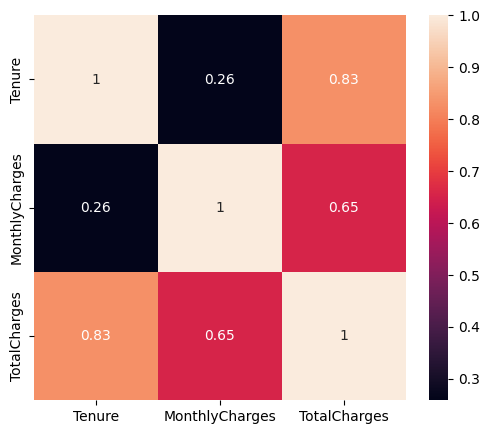

In [52]:
# pearson correlation for numerical coefficient
rcParams["figure.figsize"] = 6, 5
sns.heatmap(telecom_eda[numerical_features].corr(), annot = True)

- TotalCharges dan Tenure memiliki nilai koefisien korelasi yang besar.
- MonthlyCharges dan Tenure memiliki nilai koefisien korelasi yang kecil.
- TotalCharges dan MonthlyCharges memiliki nilai koefisien korelasi yang cukup besar.

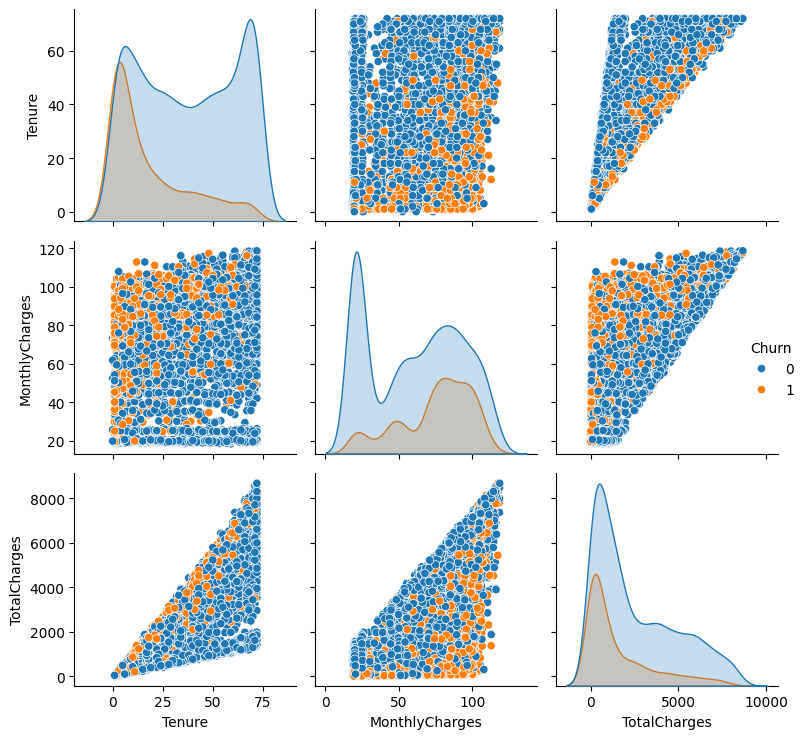

In [53]:
sns.pairplot(data = telecom_eda[numerical_features + ['Churn']], hue = "Churn", diag_kind = "kde")
plt.tight_layout()

### apa yang mempengaruhi "bimodal" pada Tenure dan MonthlyCharges?

In [54]:
# other point-biserial correlation

for i in numerical_features:
  for j in boolean_features:
    print(i, "dan", j)
    print(CorrPointBiserial(telecom_eda_pbc[i], telecom_eda_pbc[j]))
    print("")

Tenure dan SeniorCitizen
(np.float64(0.016328402380851266), np.float64(0.25202156448016505))

Tenure dan Partner
(np.float64(0.3786009995860905), np.float64(1.4258417431039713e-167))

Tenure dan Dependents
(np.float64(0.14998316205709133), np.float64(3.6637101399823703e-26))

Tenure dan PhoneService
(np.float64(0.0009350352781127719), np.float64(0.9477048424085294))

Tenure dan MultipleLines
(np.float64(0.3350529539116016), np.float64(1.9350243603746802e-129))

Tenure dan OnlineSecurity
(np.float64(0.33603620714387655), np.float64(3.0963768524463694e-130))

Tenure dan OnlineBackup
(np.float64(0.3731530748328826), np.float64(1.8064119284646213e-162))

Tenure dan DeviceProtection
(np.float64(0.36929837467656523), np.float64(6.431962053373408e-159))

Tenure dan TechSupport
(np.float64(0.3280804168913408), np.float64(7.030170728766112e-124))

Tenure dan StreamingTV
(np.float64(0.28151188283329653), np.float64(2.3841093540199183e-90))

Tenure dan StreamingMovies
(np.float64(0.29568799480829

Feature yang memiliki nilai koefisien korelasi paling besar ke kecil:
- TotalCharges: \\
  DeviceProtection (0.53) > StreamingMovies (0.52) > OnlineBackup (0.52) > StreamingTV (0.51) > MultipleLines (0.47) > TechSupport (0.43) > OnlineSecurity (0.42) > Partner (0.32) > Churn (-0.19) > PaperlessBilling (0.16) > PhoneService (0.11) > SeniorCitizen (0.10) > Dependents (0.05)

- MonthlyCharges: \\
  StreamingTV (0.63) > StreamingMovies (0.63) > MultipleLines (0.50) > DeviceProtection (0.49) > OnlineBackup (0.45) > PaperlessBilling (0.35) > TechSupport (0.34) > OnlineSecurity (0.30) > PhoneService (0.25) > SeniorCitizen (0.21) > Churn (0.20) > Dependents (-0.12) > Partner (0.10)

- Tenure: \\
  Partner (0.38) > OnlineBackup (0.37) > DeviceProtection (0.36) > Churn (-0.34) > OnlineSecurity (0.34) > MultipleLines (0.33) > TechSupport (0.32) > StreamingMovies (0.30) > StreamingTV (0.28) > Dependents (0.15) > SeniorCitizen (0.02) > PaperlessBilling (0.00) > PhoneService (0.00)


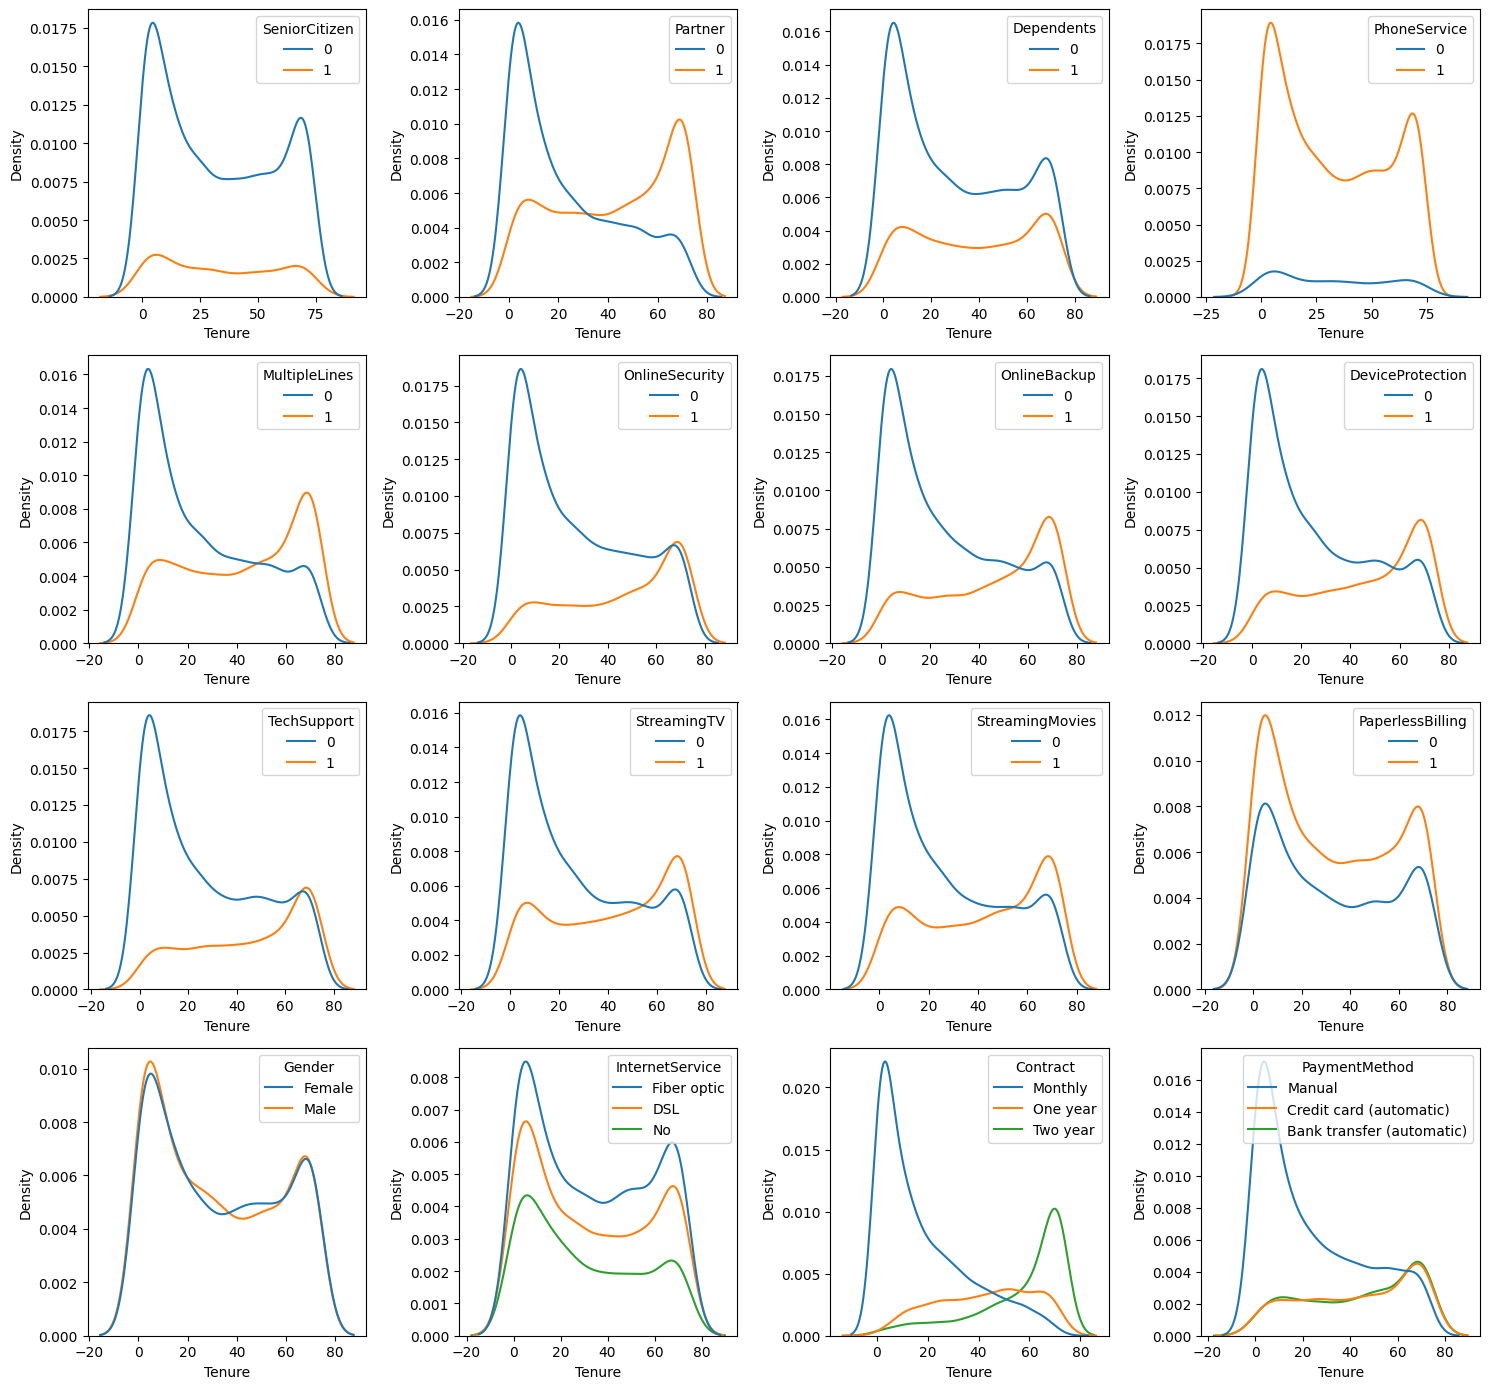

In [55]:
# feature distribution Tenure / target churn
rcParams["figure.figsize"] = 15, 3.5 * 4
for i in (boolean_features + nominal_features):
  # subplot
  plt.subplot(4, 4, (boolean_features + nominal_features).index(i) + 1)
  # class distribution
  sns.kdeplot(data = telecom_eda, x = "Tenure", hue = i)
  #plt.axvline(x = telecom_eda_churn[i].mean(), color = "g")
  #plt.axvline(x = telecom_eda_no_churn[i].mean(), color = "k")
  #plt.axvline(x = telecom_eda_churn[i].median(), linestyle = "dashed", color = "g")
  #plt.axvline(x = telecom_eda_no_churn[i].median(), linestyle = "dashed", color = "k")
  plt.tight_layout()

Berdasarkan density plot di atas, dapat dilihat bahwa feature Partner, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, dan TechSupport dapat membagi cukup baik bimodal tersebut menjadi fungsi unimodal.
- 0: Tenure terdistribusi skew positif
- 1: skew negatif

Selain itu, feature Contract juga dapat membagi bimodal Tenure dengan cukup baik.
- Monthly: skew positif, data terkonsentrasi pada Tenure 0-20. Artinya, customer dengan contract Monthly memiliki kecenderungan untuk berlangganan < satu tahun.
- One year: terdistribusi *normal*
- Two year: skew negatif, data terkonsentrasi pada Tenure 60-80

Feature PaymentMethod:
- Manual: skew positif
- Credit card (automatic) dan Bank transfer (automatic): skew negatif

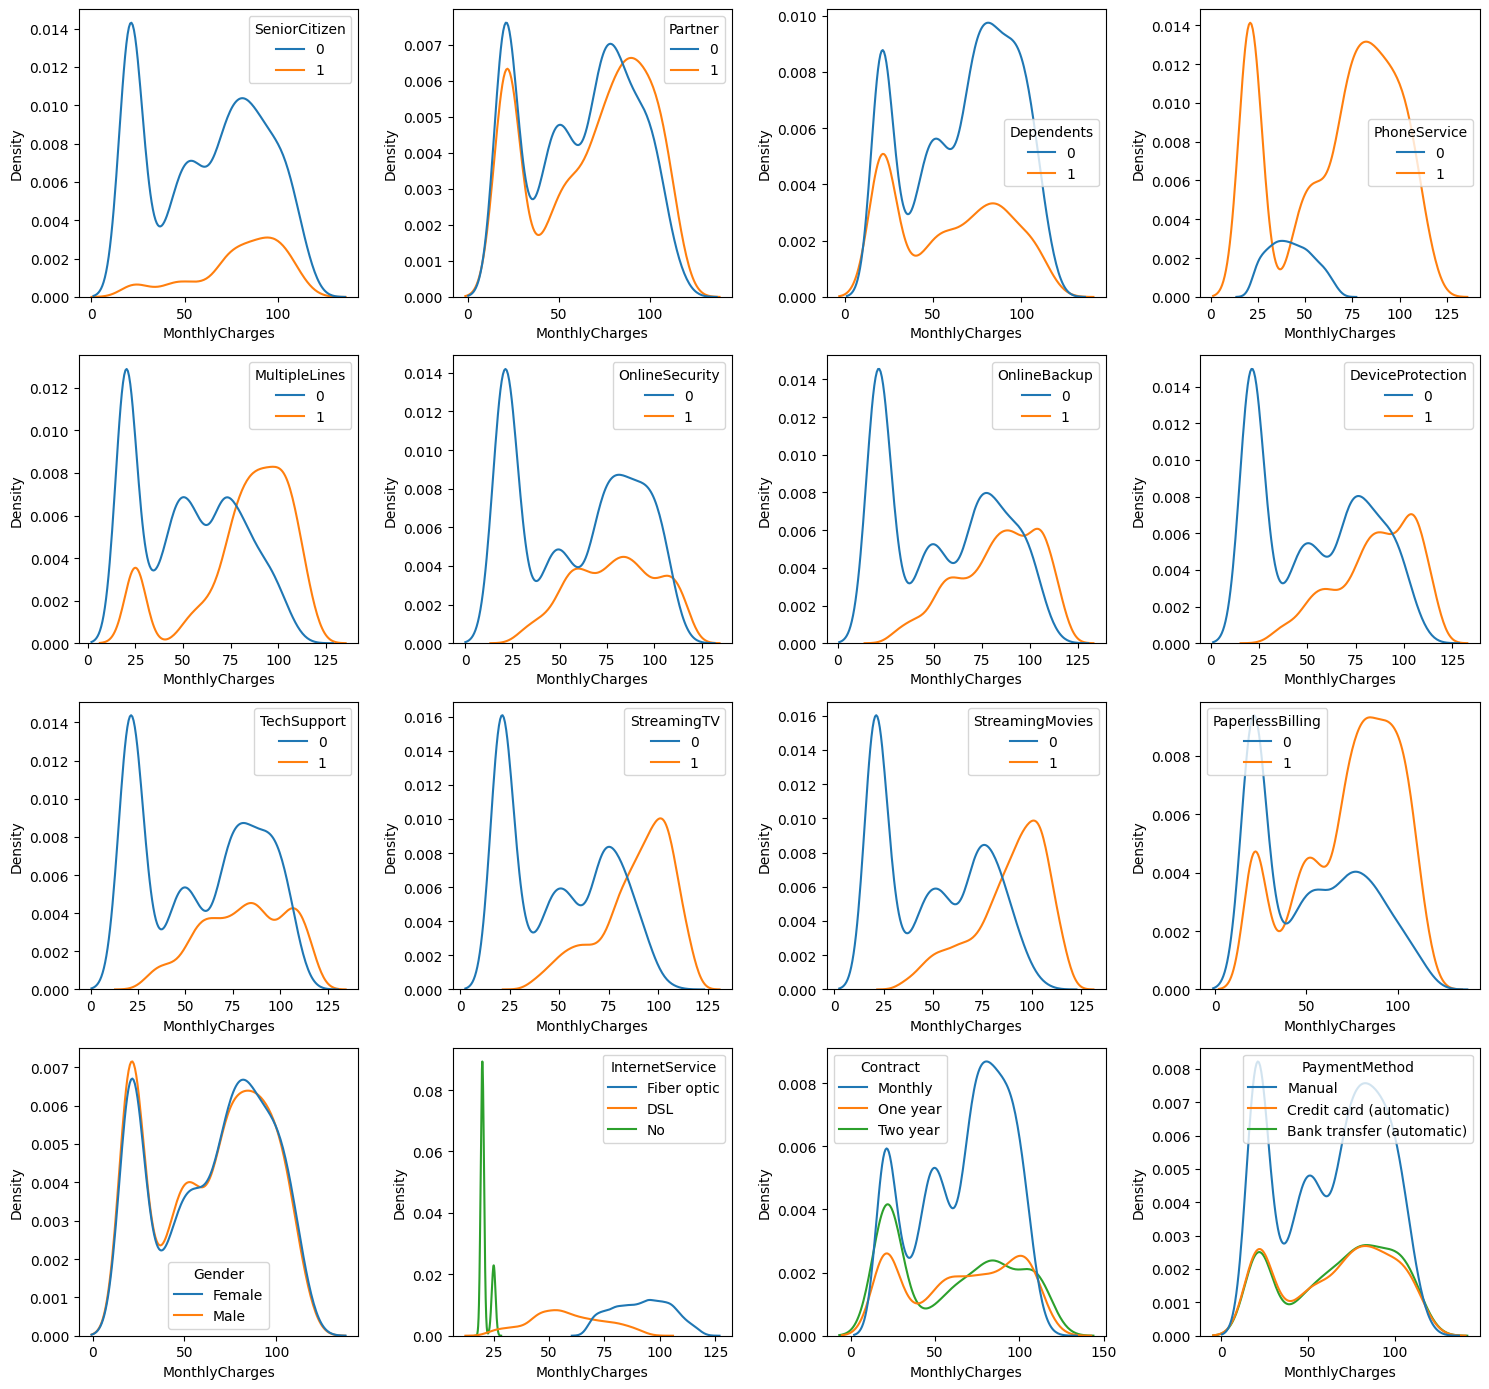

In [56]:
# feature distribution MonthlyCharges / target churn
rcParams["figure.figsize"] = 15, 3.5 * 4
for i in (boolean_features + nominal_features):
  # subplot
  plt.subplot(4, 4, (boolean_features + nominal_features).index(i) + 1)
  # class distribution
  sns.kdeplot(data = telecom_eda, x = "MonthlyCharges", hue = i)
  #plt.axvline(x = telecom_eda_churn[i].mean(), color = "g")
  #plt.axvline(x = telecom_eda_no_churn[i].mean(), color = "k")
  #plt.axvline(x = telecom_eda_churn[i].median(), linestyle = "dashed", color = "g")
  #plt.axvline(x = telecom_eda_no_churn[i].median(), linestyle = "dashed", color = "k")
  plt.tight_layout()

Tidak ada feature yang dapat membagi cukup jelas perilaku bimodal dari MonthlyCharges.

### lainnya

In [57]:
# chi-square test between dichotom features

for i in boolean_features:
  for j in boolean_features:
    if i != j:
      print(i, "dan", j)
      result_chi = Chi2Calculated(telecom_eda_pbc[i], telecom_eda_pbc[j])
      print(result_chi)

      # p-value checking
      if result_chi[1] < 0.05:
        print("H0 ditolak, dependent")
      else:
        print("H0 diterima, independent")

      print("")

SeniorCitizen dan Partner
(np.float64(1.335988579113125), np.float64(0.24774263112241077), 1, array([[2144.59739996, 1984.40260004],
       [ 412.40260004,  381.59739996]]))
H0 diterima, independent

SeniorCitizen dan Dependents
(np.float64(220.3775372582746), np.float64(7.482270457386917e-50), 1, array([[2904.47430429, 1224.52569571],
       [ 558.52569571,  235.47430429]]))
H0 ditolak, dependent

SeniorCitizen dan PhoneService
(np.float64(0.31209220110571956), np.float64(0.5763991560172579), 1, array([[ 415.16453382, 3713.83546618],
       [  79.83546618,  714.16453382]]))
H0 diterima, independent

SeniorCitizen dan MultipleLines
(np.float64(93.90165267116055), np.float64(3.3159713271024657e-22), 1, array([[2381.95409303, 1747.04590697],
       [ 458.04590697,  335.95409303]]))
H0 ditolak, dependent

SeniorCitizen dan OnlineSecurity
(np.float64(2.2871074469040202), np.float64(0.1304528400011679), 1, array([[2937.18423725, 1191.81576275],
       [ 564.81576275,  229.18423725]]))
H0 di

### summary bagian tiga

Seputar features data:

***Exploration***
- Nilai koefisien korelasi antara TotalCharges dan Tenure sangat besar (0.83)

***Data Preprocessing: Selection/Feature Engineering*** \\
- Opsi pilih salah satu antara TotalCharges dan Tenure, atau
- Buat feature baru Avg_Charges_per_Month = TotalCharges/Tenure

Insight:

**Tenure** \\
Berdasarkan bagian sebelumnya, diperoleh bahwa Tenure dan Churn memiliki nilai koefisien korelasi -0.34. Hal ini sejalan dengan makna yang ada pada feature Tenure. Semakin besar nilai Tenure (semakin lama customer berlangganan), maka customer cenderung akan bertahan.

Sementara itu, berdasarkan plot di atas dapat diperoleh insight terkait customer dengan nilai Tenure yang cukup tinggi (60-80 bulan, >5 tahun):
- Customer yang memiliki Partner
- Mempunyai layanan MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, dan TechSupport
- Menggunakan paket layanan Contract Two year
- Menggunakan PaymentMethod Credit card, Bank transfer

## Outlier checking

In [58]:
# outlier checking

# function to detect outlier using IQR
def detect_outliers_iqr(data):

    # initialize list that contains the outliers
    outliers = []

    # compute the q1
    q1 = data.quantile(0.25)

    # compute the q3
    q3 = data.quantile(0.75)

    # compute the IQR
    IQR = q3 - q1

    # set the lower bound
    ## note that we can play with value 1.5 to widen or narrow the range
    lwr_bound = q1 - (1.5*IQR)

    # set the upper bound
    ## note that we can play with value 1.5 to widen or narrow the range
    upr_bound = q3 + (1.5*IQR)

    # print computed lower and upper bound of a particular column
    print("lower:", lwr_bound, "upper:", upr_bound)

    # for each data point, decide whether it falls below lower bound or above upper ground
    for i in data:
        if (i < lwr_bound or i > upr_bound):
            outliers.append(i)

    return outliers

In [59]:
# detect outlier from numerical features

for i in numerical_features:
  print(i)

  # outlier
  if len(detect_outliers_iqr(telecom_eda[i])) > 0:
    print(detect_outliers_iqr(telecom_eda[i]))
  else:
    print("No outlier")

  print("")

Tenure
lower: -61.5 upper: 126.5
No outlier

MonthlyCharges
lower: -46.32499999999999 upper: 171.875
No outlier

TotalCharges
lower: -4790.95 upper: 9051.05
No outlier



Tidak ada outlier yang terdeteksi pada numerical features berdasarkan IQR method.

## Summary


**Imputation**
- categorical:
  - Gender: Modus
  - Lainnya: Modus kelas
- numerik:
  - Tenure: Mean kelas
  - MonthlyCharges: Mean kelas
  - TotalCharges: Median kelas

**Selection**
- Opsi: drop Gender, PhoneService

**Encoding**
- OHE categorical features

**Engineering**
- Feature baru: \\
  Avg_Charges_per_Month = TotalCharges/Tenure

**Imbalanced Class**
- Handling imbalance dataset untuk Churn

# Data Preprocessing

In [60]:
# library
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [61]:
# load data

# train set
train_dataset = pd.concat([X_train, y_train], axis = 1)

# valid set
valid_dataset = pd.concat([X_valid, y_valid], axis = 1)

# test set
test_dataset = pd.concat([X_test, y_test], axis = 1)

## Dataset train

In [62]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4930 entries, 5557 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            4930 non-null   object 
 1   SeniorCitizen     4930 non-null   int64  
 2   Partner           4930 non-null   int64  
 3   Dependents        4930 non-null   int64  
 4   Tenure            4930 non-null   int64  
 5   PhoneService      4930 non-null   int64  
 6   MultipleLines     4930 non-null   int64  
 7   InternetService   4930 non-null   object 
 8   OnlineSecurity    4930 non-null   int64  
 9   OnlineBackup      4930 non-null   int64  
 10  DeviceProtection  4930 non-null   int64  
 11  TechSupport       4930 non-null   int64  
 12  StreamingTV       4930 non-null   int64  
 13  StreamingMovies   4930 non-null   int64  
 14  Contract          4930 non-null   object 
 15  PaperlessBilling  4930 non-null   int64  
 16  PaymentMethod     4930 non-null   object 
 1

### Cleaning dataset

In [63]:
# function for imputation, drop customerID, drop duplicates

def clean_data (data):

  # drop duplicates row
  data = data.drop_duplicates(keep = "first")

  # imputation missing values TotalCharges
  impute_tc_churn = data[data.Churn == 1].TotalCharges.median()
  impute_tc_no_churn = data[data.Churn == 0].TotalCharges.median()

  data.loc[data[((data.Churn == 1) & (data.TotalCharges.isnull() == True))].index, "TotalCharges"] = impute_tc_churn
  data.loc[data[((data.Churn == 0) & (data.TotalCharges.isnull() == True))].index, "TotalCharges"] = impute_tc_no_churn

  return data

In [64]:
train_cleaned = clean_data(train_dataset)

train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4917 entries, 5557 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            4917 non-null   object 
 1   SeniorCitizen     4917 non-null   int64  
 2   Partner           4917 non-null   int64  
 3   Dependents        4917 non-null   int64  
 4   Tenure            4917 non-null   int64  
 5   PhoneService      4917 non-null   int64  
 6   MultipleLines     4917 non-null   int64  
 7   InternetService   4917 non-null   object 
 8   OnlineSecurity    4917 non-null   int64  
 9   OnlineBackup      4917 non-null   int64  
 10  DeviceProtection  4917 non-null   int64  
 11  TechSupport       4917 non-null   int64  
 12  StreamingTV       4917 non-null   int64  
 13  StreamingMovies   4917 non-null   int64  
 14  Contract          4917 non-null   object 
 15  PaperlessBilling  4917 non-null   int64  
 16  PaymentMethod     4917 non-null   object 
 1

### Feature Engineering

In [65]:
# function to create new feature

def feature_engineering (data):

  # create new feature
  data["Tenure"] = data["Tenure"].replace(0, 1)

  data["Avg_Charges_per_Month"] = data["TotalCharges"] / data["Tenure"]
  data["Avg_Charges_per_Month"] = data["Avg_Charges_per_Month"].round(2)

  # delete TotalCharges and Tenure
  data = data.drop(columns = ["TotalCharges", "Tenure"]).copy()

  return data

In [66]:
# feature engineering
train_new = feature_engineering(train_cleaned)
train_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4917 entries, 5557 to 5639
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 4917 non-null   object 
 1   SeniorCitizen          4917 non-null   int64  
 2   Partner                4917 non-null   int64  
 3   Dependents             4917 non-null   int64  
 4   PhoneService           4917 non-null   int64  
 5   MultipleLines          4917 non-null   int64  
 6   InternetService        4917 non-null   object 
 7   OnlineSecurity         4917 non-null   int64  
 8   OnlineBackup           4917 non-null   int64  
 9   DeviceProtection       4917 non-null   int64  
 10  TechSupport            4917 non-null   int64  
 11  StreamingTV            4917 non-null   int64  
 12  StreamingMovies        4917 non-null   int64  
 13  Contract               4917 non-null   object 
 14  PaperlessBilling       4917 non-null   int64  
 15  Paymen

<ipython-input-65-27383ebea5a7>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Tenure"] = data["Tenure"].replace(0, 1)
<ipython-input-65-27383ebea5a7>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Avg_Charges_per_Month"] = data["TotalCharges"] / data["Tenure"]
<ipython-input-65-27383ebea5a7>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

### Encoding categorical features

In [67]:
# function to encode all categorical features

def encode_categorical (data, encoder_col = None, encoder = None):
  if encoder == None:
        # Buat objek
        encoder = OneHotEncoder(handle_unknown = "ignore",
                                drop = "if_binary")
        encoder.fit(data)
        encoder_col = encoder.get_feature_names_out(data.columns)

  # Transform data
  data_encoded = encoder.transform(data).toarray()
  data_encoded = pd.DataFrame(data_encoded,
                              index = data.index,
                              columns = encoder_col)

  return data_encoded, encoder_col, encoder

In [68]:
# encoding data categorical
train_encoded, encoder_col, encoder = encode_categorical(data = train_new[nominal_features])

# concat table
train_encoded = pd.concat([train_new, train_encoded], axis = 1).drop(columns = nominal_features, axis = 1).copy()

# summary
train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4917 entries, 5557 to 5639
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            4917 non-null   int64  
 1   Partner                                  4917 non-null   int64  
 2   Dependents                               4917 non-null   int64  
 3   PhoneService                             4917 non-null   int64  
 4   MultipleLines                            4917 non-null   int64  
 5   OnlineSecurity                           4917 non-null   int64  
 6   OnlineBackup                             4917 non-null   int64  
 7   DeviceProtection                         4917 non-null   int64  
 8   TechSupport                              4917 non-null   int64  
 9   StreamingTV                              4917 non-null   int64  
 10  StreamingMovies                          4917 non-

### Feature selection

In [69]:
# based on EDA, will drop Gender, PhoneService
to_drop = ["Gender_Male"]

train_encoded = train_encoded.drop(columns = to_drop)
train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4917 entries, 5557 to 5639
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            4917 non-null   int64  
 1   Partner                                  4917 non-null   int64  
 2   Dependents                               4917 non-null   int64  
 3   PhoneService                             4917 non-null   int64  
 4   MultipleLines                            4917 non-null   int64  
 5   OnlineSecurity                           4917 non-null   int64  
 6   OnlineBackup                             4917 non-null   int64  
 7   DeviceProtection                         4917 non-null   int64  
 8   TechSupport                              4917 non-null   int64  
 9   StreamingTV                              4917 non-null   int64  
 10  StreamingMovies                          4917 non-

### Rechecking data correlation

<Axes: >

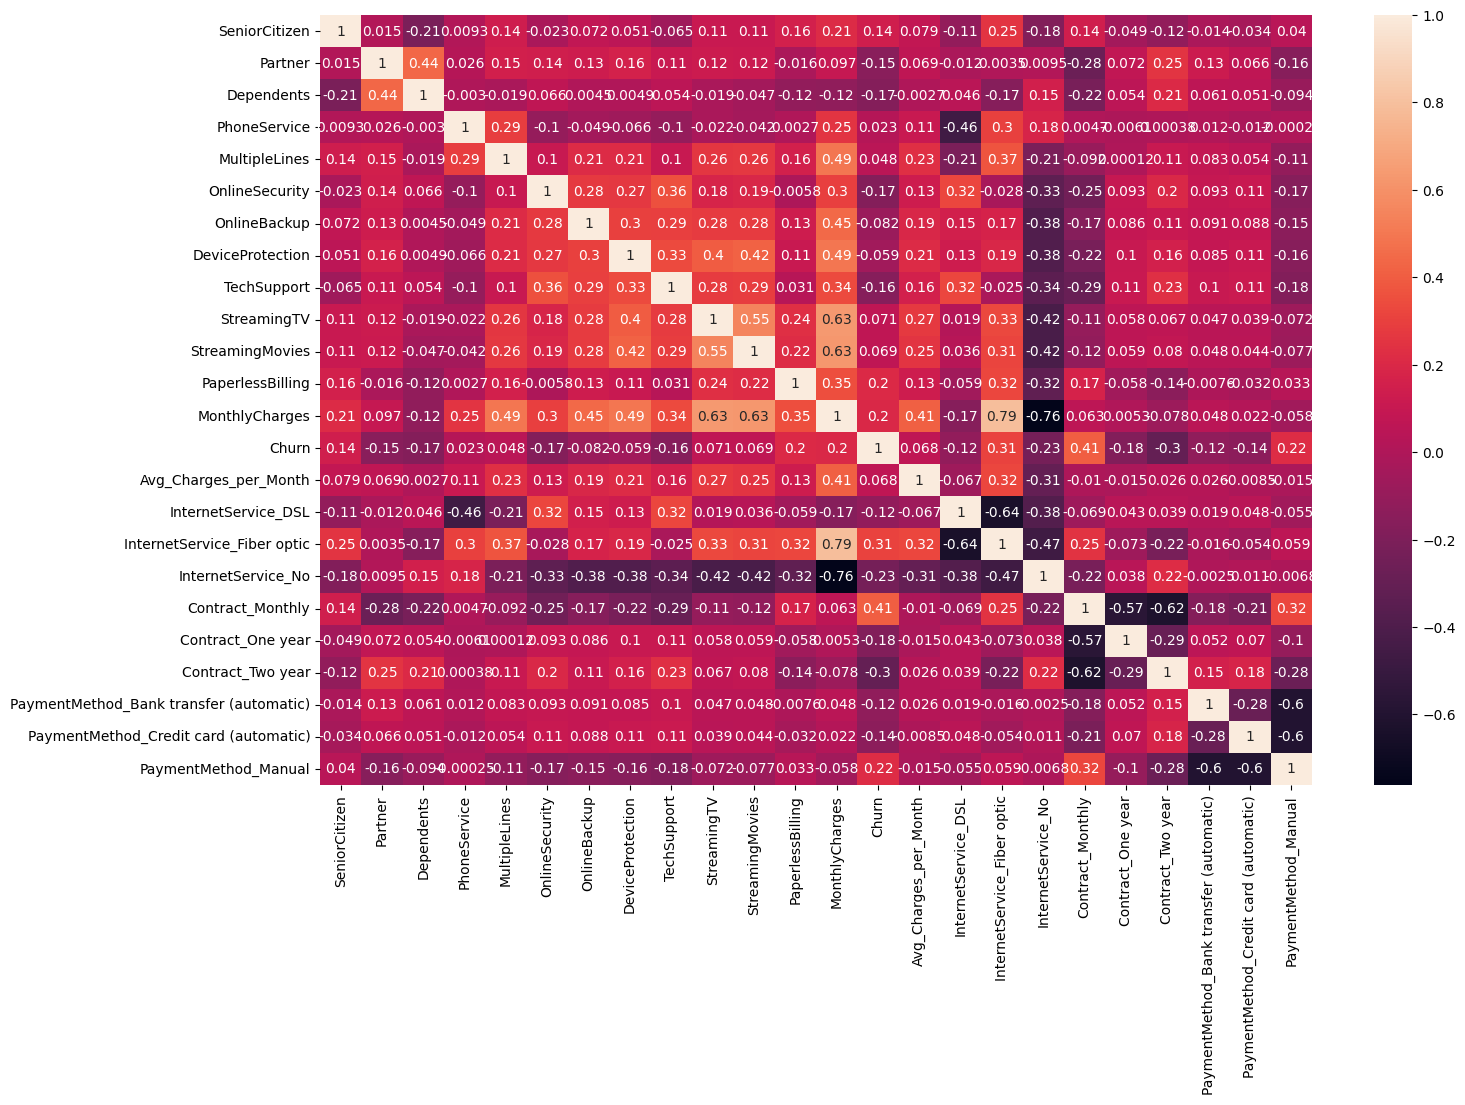

In [70]:
# pearson correlation
rcParams["figure.figsize"] = 16, 10
sns.heatmap(train_encoded.corr(), annot = True)

### Balancing Data

In [71]:
  # Split input-output
  X_train_encoded, y_train_encoded = splitInputOutput(data = train_encoded,
                                                      target_col = "Churn")

In [72]:
# cek balance data target
y_train_encoded.value_counts(normalize = True)

,proportion
Churn,
0,0.735204
1,0.264796


Data tidak balance.

In [73]:
# create object
sampling_smote = SMOTE(sampling_strategy = "minority",
                       random_state = 123)

# fit object
X_train_smote, y_train_smote = sampling_smote.fit_resample(X_train_encoded, y_train_encoded)

### Scale Data

In [74]:
def standardizeData(data, scaler):

  # Split input-output
  if "Churn" in data.columns:
    X, y = splitInputOutput(data = data,
                            target_col = "Churn")
  else:
    X = data.copy()

  if scaler == None:
    # Buat & Fit scaler
    scaler = StandardScaler()
    scaler.fit(X)
  else:
    pass

  # Tranform data
  data_scaled = scaler.transform(X)
  data_scaled = pd.DataFrame(data_scaled,
                             index = X.index,
                             columns = X.columns)

  return data_scaled, scaler

**smote**

In [75]:
# scaling data smote
X_train_smote, scaler = standardizeData(data = X_train_smote, scaler = None)
X_train_smote

,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,Avg_Charges_per_Month,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Monthly,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Manual
0,-0.406435,-0.796409,-0.536091,0.337162,-0.837841,-0.526245,-0.640454,-0.643461,-0.538015,1.254905,...,0.124763,-0.670512,0.951753,-0.44528,0.720865,-0.451772,-0.459413,-0.487622,-0.479929,0.776402
1,2.460418,-0.796409,-0.536091,0.337162,-0.837841,-0.526245,-0.640454,1.554095,-0.538015,1.254905,...,0.069612,-0.670512,0.951753,-0.44528,0.720865,-0.451772,-0.459413,-0.487622,-0.479929,0.776402
2,-0.406435,1.255636,-0.536091,0.337162,1.193544,-0.526245,-0.640454,-0.643461,-0.538015,-0.796873,...,0.045483,-0.670512,0.951753,-0.44528,0.720865,-0.451772,-0.459413,-0.487622,2.180932,-1.346271
3,-0.406435,-0.796409,-0.536091,0.337162,1.193544,-0.526245,-0.640454,1.554095,1.858686,1.254905,...,0.192496,1.497526,-1.053715,-0.44528,-1.416037,2.285984,-0.459413,-0.487622,2.180932,-1.346271
4,-0.406435,-0.796409,-0.536091,0.337162,-0.837841,1.900255,-0.640454,-0.643461,1.858686,1.254905,...,0.410172,-0.670512,0.951753,-0.44528,0.720865,-0.451772,-0.459413,2.142484,-0.479929,-1.346271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7225,-0.406435,-0.796409,-0.536091,0.337162,-0.837841,-0.526245,-0.640454,-0.643461,-0.538015,-0.796873,...,0.054971,-0.670512,0.951753,-0.44528,0.720865,-0.451772,-0.459413,-0.487622,-0.479929,0.776402
7226,-0.406435,-0.796409,-0.536091,0.337162,-0.837841,-0.526245,-0.640454,-0.643461,-0.538015,-0.796873,...,0.353912,-0.670512,0.951753,-0.44528,0.720865,-0.451772,-0.459413,-0.487622,-0.479929,0.776402
7227,-0.406435,-0.796409,-0.536091,0.337162,-0.837841,-0.526245,-0.640454,1.554095,-0.538015,-0.796873,...,0.052855,-0.670512,0.951753,-0.44528,0.720865,-0.451772,-0.459413,-0.487622,-0.479929,0.776402
7228,-0.406435,-0.796409,-0.536091,0.337162,1.193544,-0.526245,1.561392,1.554095,-0.538015,1.254905,...,0.475318,-0.670512,0.951753,-0.44528,0.720865,-0.451772,-0.459413,0.265865,-0.479929,0.168287


In [76]:
y_train_smote

,Churn
0,0
1,1
2,1
3,0
4,1
...,...
7225,1
7226,1
7227,1
7228,1


**data train**

In [77]:
# scaling data
X_train_cleaned, scaler = standardizeData(data = train_encoded, scaler = None)
X_train_cleaned

,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,Avg_Charges_per_Month,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Monthly,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Manual
5557,-0.438837,-0.965414,-0.652087,0.33495,-0.858752,-0.638177,-0.733488,-0.734144,-0.647023,1.238237,...,0.139277,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
2270,2.278749,-0.965414,-0.652087,0.33495,-0.858752,-0.638177,-0.733488,1.362131,-0.647023,1.238237,...,0.092290,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
6930,-0.438837,1.035825,-0.652087,0.33495,1.164480,-0.638177,-0.733488,-0.734144,-0.647023,-0.807600,...,0.071733,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,1.899539,-1.133045
2257,-0.438837,-0.965414,-0.652087,0.33495,1.164480,-0.638177,-0.733488,1.362131,1.545541,1.238237,...,0.196983,1.386207,-0.890260,-0.524238,-1.099498,1.937865,-0.565685,-0.532425,1.899539,-1.133045
898,-0.438837,-0.965414,-0.652087,0.33495,-0.858752,1.566964,-0.733488,-0.734144,1.545541,1.238237,...,0.382435,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,1.878197,-0.526444,-1.133045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4250,-0.438837,-0.965414,-0.652087,0.33495,1.164480,1.566964,1.363349,1.362131,1.545541,1.238237,...,0.547037,-0.721393,1.123267,-0.524238,-1.099498,1.937865,-0.565685,-0.532425,1.899539,-1.133045
1488,-0.438837,-0.965414,-0.652087,0.33495,-0.858752,1.566964,-0.733488,-0.734144,-0.647023,-0.807600,...,-0.236619,1.386207,-0.890260,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
6303,-0.438837,1.035825,-0.652087,0.33495,1.164480,-0.638177,1.363349,1.362131,1.545541,1.238237,...,0.604890,-0.721393,1.123267,-0.524238,-1.099498,-0.516032,1.767767,-0.532425,-0.526444,0.882578
2710,-0.438837,1.035825,-0.652087,0.33495,-0.858752,-0.638177,-0.733488,-0.734144,-0.647023,-0.807600,...,-0.693715,-0.721393,-0.890260,1.907532,-1.099498,1.937865,-0.565685,-0.532425,1.899539,-1.133045


In [78]:
y_train_cleaned = train_encoded["Churn"].copy()
y_train_cleaned

,Churn
5557,0
2270,1
6930,1
2257,0
898,1
...,...
4250,0
1488,0
6303,0
2710,0


## Dataset validation

In [79]:
def processingData (data, encoder_column, encoder, scaler):

  # data input: dataset contain features and target (X, y)

  # cleaning dataset
  data_cleaned = clean_data(data)

  # feature engineering
  data_new = feature_engineering(data_cleaned)

  # encoding data categorical
  data_encoded, encoder_col, encoder = encode_categorical(data = data_new[nominal_features],
                                                          encoder_col = encoder_column,
                                                          encoder = encoder)


  # concat table
  data_encoded = pd.concat([data_new, data_encoded],
                           axis = 1).drop(columns = nominal_features, axis = 1).copy()

  # feature selection
  data_encoded = data_encoded.drop(columns = to_drop)

  # scale data
  X_cleaned, scaler = standardizeData(data = data_encoded,
                                      scaler = scaler)

  # y_valid
  y_valid_cleaned = data_encoded["Churn"].copy()

  return X_cleaned, y_valid_cleaned

In [80]:
# preprocessing valid dataset

X_valid_cleaned, y_valid_cleaned = processingData(data = valid_dataset,
                                                  encoder_column = None, encoder = None,
                                                  scaler = scaler)
X_valid_cleaned

,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,Avg_Charges_per_Month,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Monthly,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Manual
6906,-0.438837,1.035825,1.533538,0.334950,-0.858752,-0.638177,-0.733488,-0.734144,-0.647023,-0.807600,...,-0.763755,-0.721393,-0.890260,1.907532,-1.099498,-0.516032,1.767767,-0.532425,-0.526444,0.882578
6015,-0.438837,-0.965414,-0.652087,0.334950,-0.858752,1.566964,-0.733488,-0.734144,-0.647023,-0.807600,...,0.154401,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
2142,-0.438837,-0.965414,1.533538,0.334950,-0.858752,1.566964,-0.733488,1.362131,-0.647023,-0.807600,...,-0.054397,1.386207,-0.890260,-0.524238,-1.099498,1.937865,-0.565685,-0.532425,-0.526444,0.882578
2080,2.278749,1.035825,-0.652087,0.334950,1.164480,1.566964,1.363349,1.362131,-0.647023,1.238237,...,0.230755,1.386207,-0.890260,-0.524238,-1.099498,-0.516032,1.767767,-0.532425,1.899539,-1.133045
6488,-0.438837,-0.965414,-0.652087,0.334950,-0.858752,-0.638177,-0.733488,-0.734144,-0.647023,-0.807600,...,0.031354,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,-0.438837,-0.965414,-0.652087,0.334950,1.164480,-0.638177,1.363349,1.362131,-0.647023,-0.807600,...,0.438526,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,1.899539,-1.133045
485,-0.438837,1.035825,1.533538,0.334950,1.164480,-0.638177,-0.733488,-0.734144,-0.647023,-0.807600,...,0.261150,-0.721393,1.123267,-0.524238,-1.099498,-0.516032,1.767767,-0.532425,1.899539,-1.133045
2168,2.278749,1.035825,-0.652087,0.334950,1.164480,-0.638177,-0.733488,-0.734144,-0.647023,-0.807600,...,0.118133,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
5066,-0.438837,1.035825,-0.652087,-2.985516,-0.858752,-0.638177,1.363349,1.362131,-0.647023,1.238237,...,-0.191394,1.386207,-0.890260,-0.524238,-1.099498,-0.516032,1.767767,1.878197,-0.526444,-1.133045


In [81]:
# y_valid
y_valid_cleaned

,Churn
6906,0
6015,0
2142,0
2080,0
6488,1
...,...
1558,1
485,0
2168,1
5066,0


## Dataset test

In [82]:
# preprocessing test dataset

X_test_cleaned, y_test_cleaned = processingData(data = test_dataset,
                                                encoder_column = None, encoder = None,
                                                scaler = scaler)

X_test_cleaned

,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,Avg_Charges_per_Month,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Monthly,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Manual
1639,2.278749,-0.965414,-0.652087,0.334950,-0.858752,-0.638177,-0.733488,-0.734144,-0.647023,-0.807600,...,-0.323545,1.386207,-0.890260,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
3776,-0.438837,1.035825,-0.652087,0.334950,-0.858752,-0.638177,-0.733488,-0.734144,-0.647023,1.238237,...,-0.172599,1.386207,-0.890260,-0.524238,-1.099498,1.937865,-0.565685,-0.532425,-0.526444,0.882578
805,-0.438837,1.035825,1.533538,0.334950,1.164480,-0.638177,-0.733488,1.362131,-0.647023,1.238237,...,0.126062,1.386207,-0.890260,-0.524238,-1.099498,-0.516032,1.767767,1.878197,-0.526444,-1.133045
2923,-0.438837,-0.965414,-0.652087,0.334950,-0.858752,1.566964,-0.733488,1.362131,-0.647023,1.238237,...,0.279945,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
5392,-0.438837,1.035825,1.533538,-2.985516,-0.858752,-0.638177,1.363349,1.362131,1.545541,-0.807600,...,-0.430881,1.386207,-0.890260,-0.524238,-1.099498,-0.516032,1.767767,1.878197,-0.526444,-1.133045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6802,-0.438837,-0.965414,-0.652087,0.334950,1.164480,1.566964,-0.733488,-0.734144,-0.647023,1.238237,...,0.390511,-0.721393,1.123267,-0.524238,0.909506,-0.516032,-0.565685,1.878197,-0.526444,-1.133045
2777,-0.438837,-0.965414,-0.652087,0.334950,-0.858752,-0.638177,-0.733488,-0.734144,-0.647023,-0.807600,...,-0.716915,-0.721393,-0.890260,1.907532,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
5854,-0.438837,-0.965414,-0.652087,0.334950,1.164480,-0.638177,-0.733488,-0.734144,-0.647023,-0.807600,...,-0.284193,1.386207,-0.890260,-0.524238,0.909506,-0.516032,-0.565685,-0.532425,-0.526444,0.882578
5461,-0.438837,-0.965414,-0.652087,0.334950,-0.858752,1.566964,-0.733488,-0.734144,1.545541,-0.807600,...,-0.078185,1.386207,-0.890260,-0.524238,-1.099498,-0.516032,1.767767,-0.532425,-0.526444,0.882578


In [83]:
# y_test
y_test_cleaned

,Churn
1639,1
3776,0
805,0
2923,0
5392,0
...,...
6802,0
2777,0
5854,0
5461,0


# Modeling

## Baseline model

In [84]:
y_train_cleaned.value_counts(normalize = True)

,proportion
Churn,
0,0.735204
1,0.264796


In [85]:
# import libraries

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score, confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score
from sklearn.model_selection import cross_validate

In [86]:
# create function for model score evaluation

def eval_classification(model, X_train, y_train, X_test, y_test):

  # prediction (0/1)
  y_pred_train = model.predict(X_train)
  y_pred = model.predict(X_test)

  # probability prediction (0-1)
  y_pred_proba_train = model.predict_proba(X_train)
  y_pred_proba = model.predict_proba(X_test)

  # evaluation score
  print("Score: ", model)
  print("")

  print("Accuracy Score(Train set): %.2f" % accuracy_score(y_train, y_pred_train))
  print("Accuracy Score(Test set): %.2f" % accuracy_score(y_test, y_pred))

  print("Precision Score (Train set):%.2f" % precision_score(y_train, y_pred_train))
  print("Precision Score (Test set):%.2f" % precision_score(y_test, y_pred))

  print("Recall Score (Train set):%.2f" % recall_score(y_train, y_pred_train))
  print("Recall Score (Test set):%.2f" % recall_score(y_test, y_pred))

  print("F1 Score (Train set):%.2f" % f1_score(y_train, y_pred_train))
  print("F1 Score (Test set):%.2f" % f1_score(y_test, y_pred))

  print("ROC AUC Score (Train-proba): %.2f" % roc_auc_score (y_train, y_pred_proba_train[:,1]))
  print("ROC AUC Score (Test-proba): %.2f" % roc_auc_score (y_test, y_pred_proba[:,1]))

## Model Evaluation

### data train sampling smote

In [87]:
# logistic regression
lr = LogisticRegression(random_state = 123)
lr.fit(X_train_smote, y_train_smote)

# basic model (data train smote)
eval_classification(lr, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  LogisticRegression(random_state=123)

Accuracy Score(Train set): 0.80
Accuracy Score(Test set): 0.67
Precision Score (Train set):0.79
Precision Score (Test set):0.44
Recall Score (Train set):0.82
Recall Score (Test set):0.89
F1 Score (Train set):0.80
F1 Score (Test set):0.59
ROC AUC Score (Train-proba): 0.89
ROC AUC Score (Test-proba): 0.81


In [88]:
# k-nearest neighbor
knn = KNeighborsClassifier()
knn.fit(X_train_smote, y_train_smote)

# basic model (data train smote)
eval_classification(knn, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  KNeighborsClassifier()

Accuracy Score(Train set): 0.85
Accuracy Score(Test set): 0.70
Precision Score (Train set):0.82
Precision Score (Test set):0.45
Recall Score (Train set):0.90
Recall Score (Test set):0.69
F1 Score (Train set):0.86
F1 Score (Test set):0.55
ROC AUC Score (Train-proba): 0.94
ROC AUC Score (Test-proba): 0.74


In [89]:
# decision tree
dt = DecisionTreeClassifier(random_state = 123)
dt.fit(X_train_smote, y_train_smote)

# basic model (data train smote)
eval_classification(dt, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  DecisionTreeClassifier(random_state=123)

Accuracy Score(Train set): 1.00
Accuracy Score(Test set): 0.39
Precision Score (Train set):1.00
Precision Score (Test set):0.25
Recall Score (Train set):1.00
Recall Score (Test set):0.67
F1 Score (Train set):1.00
F1 Score (Test set):0.37
ROC AUC Score (Train-proba): 1.00
ROC AUC Score (Test-proba): 0.48


In [90]:
# random forest
rf = RandomForestClassifier(random_state = 123)
rf.fit(X_train_smote, y_train_smote)

# basic model (data train smote)
eval_classification(rf, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  RandomForestClassifier(random_state=123)

Accuracy Score(Train set): 1.00
Accuracy Score(Test set): 0.38
Precision Score (Train set):1.00
Precision Score (Test set):0.27
Recall Score (Train set):1.00
Recall Score (Test set):0.77
F1 Score (Train set):1.00
F1 Score (Test set):0.39
ROC AUC Score (Train-proba): 1.00
ROC AUC Score (Test-proba): 0.56


In [91]:
# adaboost
from sklearn.ensemble import AdaBoostClassifier
ab = AdaBoostClassifier()
ab.fit(X_train_smote, y_train_smote)

# basic model
eval_classification(ab,  X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  AdaBoostClassifier()

Accuracy Score(Train set): 0.80
Accuracy Score(Test set): 0.32
Precision Score (Train set):0.78
Precision Score (Test set):0.28
Recall Score (Train set):0.84
Recall Score (Test set):0.98
F1 Score (Train set):0.81
F1 Score (Test set):0.43
ROC AUC Score (Train-proba): 0.89
ROC AUC Score (Test-proba): 0.58


In [92]:
# xgboost
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train_smote, y_train_smote)

# basic model
eval_classification(xgb, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

Accuracy Score(Train set): 0.94
Accuracy Score(Test set): 0.27
Precision Score (Train set):0.92
Precision Score (Test set):0.27
Recall Score (Train set):0.96
Recall Score (Test set):1.00
F1 Score (Train set):0.94
F1 Score (Test set):

### data train (imbalance)

In [93]:
# logistic regression
lr = LogisticRegression(random_state = 123)
lr.fit(X_train_smote, y_train_smote)

# basic model (data train)
eval_classification(lr, X_train_cleaned, y_train_cleaned, X_valid_cleaned, y_valid_cleaned)

Score:  LogisticRegression(random_state=123)

Accuracy Score(Train set): 0.68
Accuracy Score(Test set): 0.67
Precision Score (Train set):0.45
Precision Score (Test set):0.44
Recall Score (Train set):0.87
Recall Score (Test set):0.89
F1 Score (Train set):0.59
F1 Score (Test set):0.59
ROC AUC Score (Train-proba): 0.82
ROC AUC Score (Test-proba): 0.81


In [94]:
# k-nearest neighbor
knn = KNeighborsClassifier()
knn.fit(X_train_smote, y_train_smote)

# basic model (data train)
eval_classification(knn, X_train_cleaned, y_train_cleaned, X_valid_cleaned, y_valid_cleaned)

Score:  KNeighborsClassifier()

Accuracy Score(Train set): 0.78
Accuracy Score(Test set): 0.70
Precision Score (Train set):0.56
Precision Score (Test set):0.45
Recall Score (Train set):0.81
Recall Score (Test set):0.69
F1 Score (Train set):0.66
F1 Score (Test set):0.55
ROC AUC Score (Train-proba): 0.88
ROC AUC Score (Test-proba): 0.74


In [95]:
# decision tree
dt = DecisionTreeClassifier(random_state = 123)
dt.fit(X_train_smote, y_train_smote)

# basic model (data train)
eval_classification(dt, X_train_cleaned, y_train_cleaned, X_valid_cleaned, y_valid_cleaned)

Score:  DecisionTreeClassifier(random_state=123)

Accuracy Score(Train set): 0.43
Accuracy Score(Test set): 0.39
Precision Score (Train set):0.28
Precision Score (Test set):0.25
Recall Score (Train set):0.77
Recall Score (Test set):0.67
F1 Score (Train set):0.42
F1 Score (Test set):0.37
ROC AUC Score (Train-proba): 0.54
ROC AUC Score (Test-proba): 0.48


In [96]:
# random forest
rf = RandomForestClassifier(random_state = 123)
rf.fit(X_train_smote, y_train_smote)

# basic model (data train)
eval_classification(rf, X_train_cleaned, y_train_cleaned, X_valid_cleaned, y_valid_cleaned)

Score:  RandomForestClassifier(random_state=123)

Accuracy Score(Train set): 0.42
Accuracy Score(Test set): 0.38
Precision Score (Train set):0.30
Precision Score (Test set):0.27
Recall Score (Train set):0.88
Recall Score (Test set):0.77
F1 Score (Train set):0.45
F1 Score (Test set):0.39
ROC AUC Score (Train-proba): 0.68
ROC AUC Score (Test-proba): 0.56


In [97]:
# adaboost
from sklearn.ensemble import AdaBoostClassifier
ab = AdaBoostClassifier()
ab.fit(X_train_smote, y_train_smote)

# basic model (data train)
eval_classification(ab,  X_train_cleaned, y_train_cleaned, X_valid_cleaned, y_valid_cleaned)

Score:  AdaBoostClassifier()

Accuracy Score(Train set): 0.32
Accuracy Score(Test set): 0.32
Precision Score (Train set):0.28
Precision Score (Test set):0.28
Recall Score (Train set):0.98
Recall Score (Test set):0.98
F1 Score (Train set):0.43
F1 Score (Test set):0.43
ROC AUC Score (Train-proba): 0.57
ROC AUC Score (Test-proba): 0.58


In [98]:
# xgboost
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train_smote, y_train_smote)

# basic model (data train)
eval_classification(xgb, X_train_cleaned, y_train_cleaned, X_valid_cleaned, y_valid_cleaned)

Score:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

Accuracy Score(Train set): 0.26
Accuracy Score(Test set): 0.27
Precision Score (Train set):0.26
Precision Score (Test set):0.27
Recall Score (Train set):1.00
Recall Score (Test set):1.00
F1 Score (Train set):0.42
F1 Score (Test set):

### summary bagian satu

- Modeling berfokus pada customer churn dengan metrics recall dan ROC-AUC.
- Pada model latih menggunakan *data train smote*, model yang menghasilnya nilai score Recall dan ROC AUC pada data training dan data test yang cukup baik adalah:
  - Logistic Regression (score cukup baik, ada sedikit kecenderungan underfitting)
  - K-Nearest Neighbor (score cukup baik, cenderung overfitting)

## Logistic Regression

In [99]:
# import model
lr = LogisticRegression(random_state = 123)
lr.fit(X_train_smote, y_train_smote)

# basic model (data train smote)
eval_classification(lr, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  LogisticRegression(random_state=123)

Accuracy Score(Train set): 0.80
Accuracy Score(Test set): 0.67
Precision Score (Train set):0.79
Precision Score (Test set):0.44
Recall Score (Train set):0.82
Recall Score (Test set):0.89
F1 Score (Train set):0.80
F1 Score (Test set):0.59
ROC AUC Score (Train-proba): 0.89
ROC AUC Score (Test-proba): 0.81


Text(0.5, 1.0, 'Feature importance using Logistic Regression')

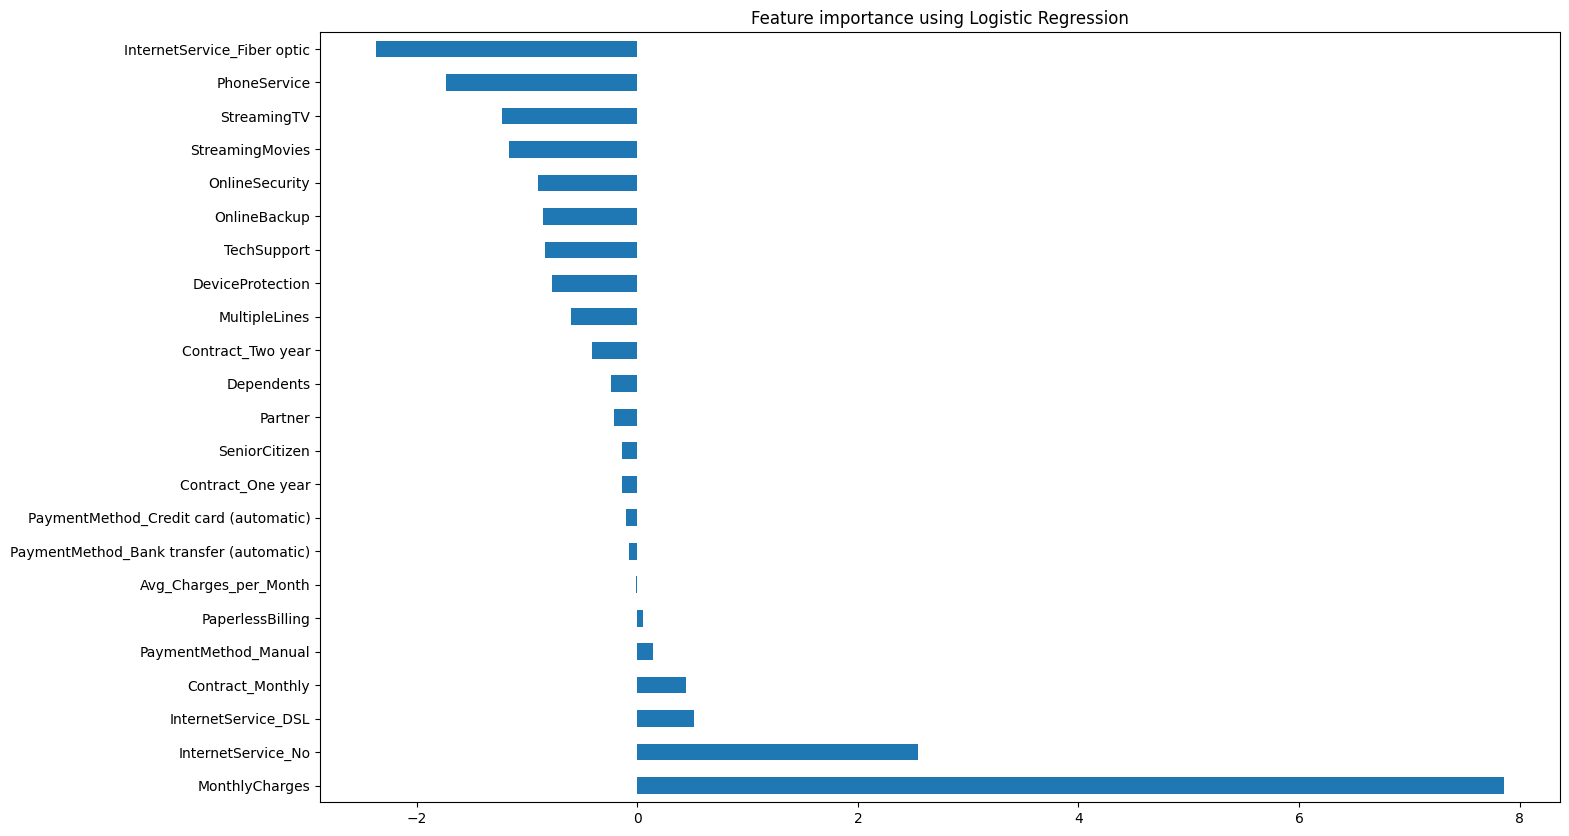

In [100]:
# features coefficient
coef = pd.Series(lr.coef_[0], index = X_train_smote.columns)
imp_coef = coef.sort_values(ascending = False)

# plot importance
imp_coef.plot(kind = "barh")
plt.title("Feature importance using Logistic Regression")

Berdasarkan nilai koefisien feature dari pemodelan regresi logistic di atas, diperoleh bahwa feature yang berpengaruh terhadap Churn:
- Positive corr: MonthlyCharges, InternetService_No, InternetService_DSL, Contract_Monthly
- Negative corr: InternetService_Fiber optic, PhoneService, StreamingTV, StreamingMovies, OnlineSecurity, OnlineBackup, TechSupport, DeviceProtection, MultipleLines, Contract_Two year, Dependents, Partner

Dari hasil tersebut di atas, terdapat perbedaan dengan hasil eksplorasi sebelumnya. Di mana, pada hasil eksplorasi, Partner, Dependents, SeniorCitizen, dan Contract berpengaruh terhadap customer churn.

In [101]:
# learning curve model

def draw_learning_curve_logreg(param_values, X, y, X1, y1):
    train_scores = []
    test_scores = []

    for c in param_values:
        model = LogisticRegression(penalty = 'l2', C = c)
        model.fit(X, y)

        # prediction (0/1)
        y_pred_train = model.predict(X)
        y_pred = model.predict(X1)

        # eval on train
        y_pred_train_proba = model.predict_proba(X)
        train_auc = roc_auc_score(y, y_pred_train_proba[:,1])
        train_scores.append(train_auc)

        # eval on test
        y_pred_proba = model.predict_proba(X1)
        test_auc = roc_auc_score(y1, y_pred_proba[:,1])
        test_scores.append(test_auc)

        print('param_values: ' + str(c) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc) + '; div: '+ str(train_auc - test_auc) +
              '; train: ' + str(recall_score(y, y_pred_train)) + '; test: '+ str(recall_score(y1, y_pred)) + '; div: '+ str(recall_score(y, y_pred_train) - recall_score(y1, y_pred)))



    plt.plot(param_values, train_scores, label='Train')
    plt.plot(param_values, test_scores, label='Test')
    plt.xlabel('C')
    plt.ylabel('AUC')
    plt.title('Learning Curve - Hyperparameter C - Logistic Regression')
    plt.legend()
    plt.show()

param_values: 0.1; train: 0.8834772128579051; test: 0.8108408505154641; div: 0.07263636234244109; train: 0.8174273858921162; test: 0.8678571428571429; div: -0.05042975696502672
param_values: 0.31052631578947365; train: 0.8881512217611803; test: 0.8099525957290133; div: 0.07819862603216698; train: 0.8218533886583679; test: 0.875; div: -0.05314661134163212
param_values: 0.5210526315789473; train: 0.8894287479745719; test: 0.8088434278350516; div: 0.08058532013952036; train: 0.8218533886583679; test: 0.8821428571428571; div: -0.06028946848448924
param_values: 0.731578947368421; train: 0.8900616571875676; test: 0.8078125000000002; div: 0.08224915718756742; train: 0.8215767634854771; test: 0.8857142857142857; div: -0.06413752222880853
param_values: 0.9421052631578947; train: 0.8904055447468956; test: 0.8069748711340206; div: 0.08343067361287504; train: 0.8210235131396957; test: 0.8857142857142857; div: -0.06469077257459
param_values: 1.1526315789473685; train: 0.8905850641537011; test: 0.80

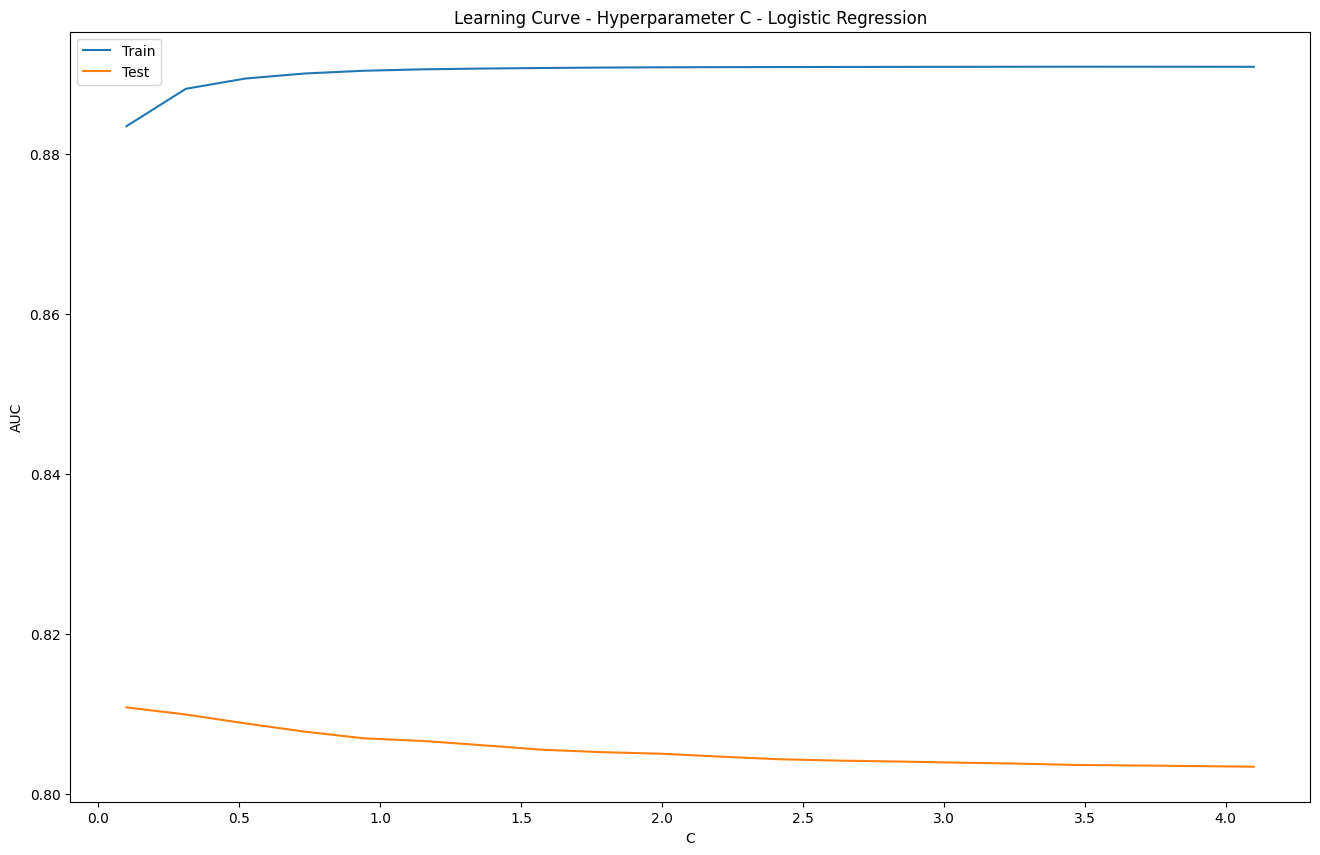

In [102]:
# finding c hyperparameter value
param_values = [float(x) for x in np.linspace(0.1, 4.1 , 20)]
draw_learning_curve_logreg(param_values, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

In [103]:
# model using parameter

# import model
lr = LogisticRegression(penalty = "l2", C = 0.1,
                        random_state = 123)

# fitting model
lr.fit(X_train_smote, y_train_smote)

# score
eval_classification(lr, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  LogisticRegression(C=0.1, random_state=123)

Accuracy Score(Train set): 0.79
Accuracy Score(Test set): 0.68
Precision Score (Train set):0.78
Precision Score (Test set):0.45
Recall Score (Train set):0.82
Recall Score (Test set):0.87
F1 Score (Train set):0.80
F1 Score (Test set):0.59
ROC AUC Score (Train-proba): 0.88
ROC AUC Score (Test-proba): 0.81


- Setelah dilakukan hyperparameter tuning, tidak ada perbaikan skor yang signifikan.
- Akan dilakukan ulang data preprocessing jika diperlukan.

## K-Nearest Neighbor Classifier

In [104]:
# import model
knn = KNeighborsClassifier()
knn.fit(X_train_smote, y_train_smote)

# basic model (data train smote)
eval_classification(knn, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  KNeighborsClassifier()

Accuracy Score(Train set): 0.85
Accuracy Score(Test set): 0.70
Precision Score (Train set):0.82
Precision Score (Test set):0.45
Recall Score (Train set):0.90
Recall Score (Test set):0.69
F1 Score (Train set):0.86
F1 Score (Test set):0.55
ROC AUC Score (Train-proba): 0.94
ROC AUC Score (Test-proba): 0.74


In [105]:
# learning curve model

def draw_learning_curve_knn(param_values, X, y, X1, y1):
    train_scores = []
    test_scores = []

    for i in param_values:
        model = KNeighborsClassifier(n_neighbors = i)
        model.fit(X, y)

        # prediction (0/1)
        y_pred_train = model.predict(X)
        y_pred = model.predict(X1)

        # eval on train
        y_pred_train_proba = model.predict_proba(X)
        train_auc = roc_auc_score(y, y_pred_train_proba[:,1])
        train_scores.append(train_auc)

        # eval on test
        y_pred_proba = model.predict_proba(X1)
        test_auc = roc_auc_score(y1, y_pred_proba[:,1])
        test_scores.append(test_auc)

        print('param value: ' + str(i) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc) + '; div: ' + str(train_auc-test_auc) +
              '; train: ' + str(recall_score(y, y_pred_train)) + '; test: '+ str(recall_score(y1, y_pred)) + '; div: '+ str(recall_score(y, y_pred_train) - recall_score(y1, y_pred)))

    plt.plot(param_values, train_scores, label='Train')
    plt.plot(param_values, test_scores, label='Test')
    plt.xlabel('k')
    plt.ylabel('AUC')
    plt.title('Learning Curve')
    plt.legend()
    plt.show()

param value: 1; train: 0.9980636237897649; test: 0.6165316642120766; div: 0.38153195957768826; train: 0.9983402489626556; test: 0.5178571428571429; div: 0.4804831061055127
param value: 2; train: 0.9763317129908614; test: 0.6845130706921945; div: 0.29181864229866694; train: 0.8088520055325035; test: 0.4107142857142857; div: 0.3981377198182178
param value: 3; train: 0.9613093208909397; test: 0.711952319587629; div: 0.24935700130331073; train: 0.9161825726141078; test: 0.6678571428571428; div: 0.24832542975696503
param value: 4; train: 0.9492013261173572; test: 0.7277729197349042; div: 0.22142840638245298; train: 0.827939142461964; test: 0.55; div: 0.27793914246196394
param value: 5; train: 0.9402946459829089; test: 0.7436993740795287; div: 0.19659527190338022; train: 0.9009681881051176; test: 0.6892857142857143; div: 0.2116824738194033
param value: 6; train: 0.9331608921640084; test: 0.749242912371134; div: 0.1839179797928744; train: 0.8475795297372061; test: 0.625; div: 0.22257952973720

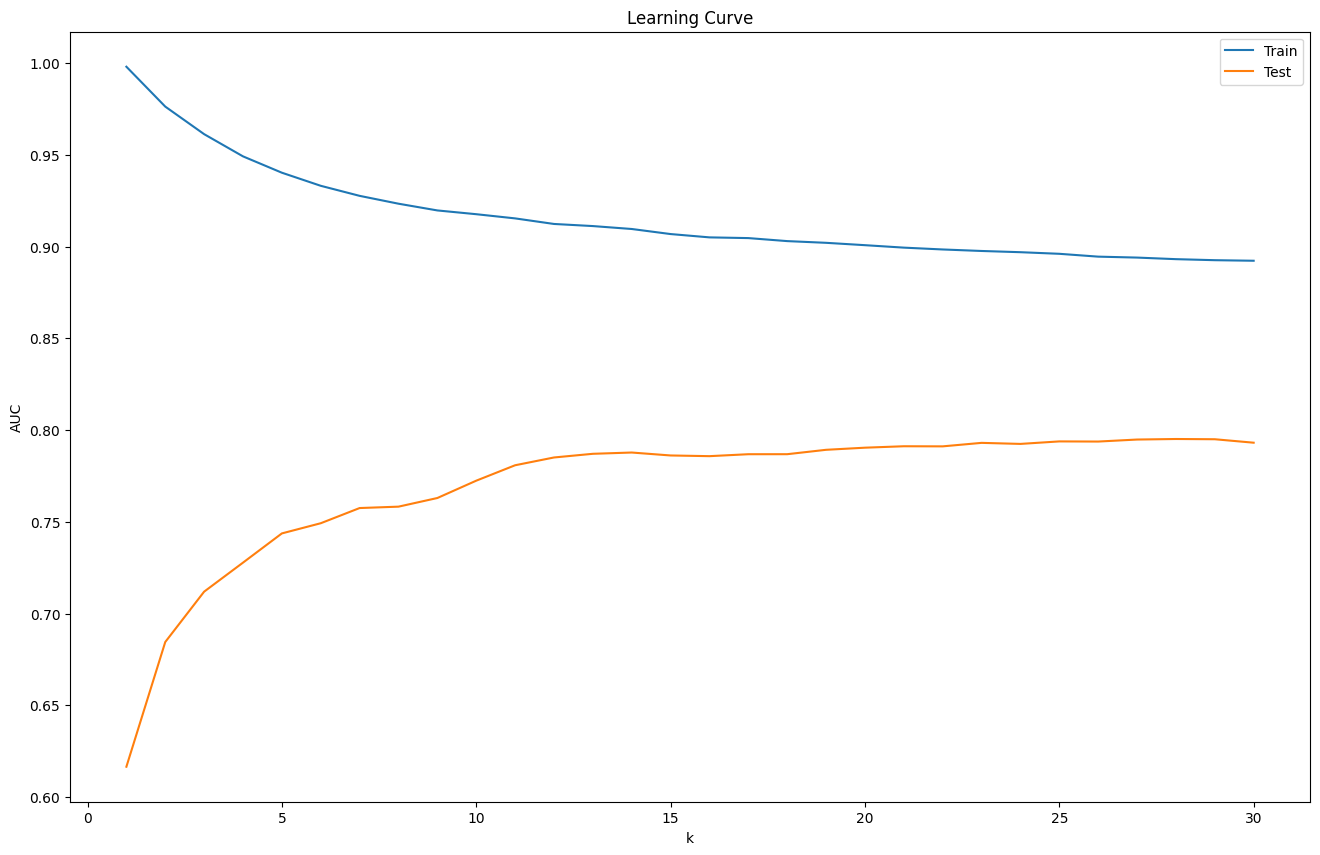

In [106]:
param_values = [int(x) for x in np.linspace(1, 30, 30)]
draw_learning_curve_knn(param_values, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

In [107]:
def knn_tuning(n_neighbors, p, algorithm,
               X, y, X1, y1):

  # hyperparameter
  hyperparameters = dict(n_neighbors = n_neighbors,
                         p = p,
                         algorithm = algorithm)

  # import model
  knn = KNeighborsClassifier()
  knn_tuned = RandomizedSearchCV(knn, hyperparameters, scoring = 'roc_auc', random_state = 123, cv = 5)
  knn_tuned.fit(X, y)

  print('Best n_neighbors:', knn_tuned.best_estimator_.get_params()['n_neighbors'])
  print('Best p:', knn_tuned.best_estimator_.get_params()['p'])
  print('Best weights:', knn_tuned.best_estimator_.get_params()['weights'])
  print('Best algorithm:', knn_tuned.best_estimator_.get_params()['algorithm'])
  print('Best score:', knn_tuned.best_score_)
  print("")

  eval_classification(knn_tuned, X, y, X1, y1)

In [108]:
n_neighbors = [25, 26, 27, 28, 29, 30]
p = [1, 2]
algorithm = ['auto', 'ball_tree', 'kd_tree', 'brute']

knn_tuning(n_neighbors, p, algorithm, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Best n_neighbors: 26
Best p: 1
Best weights: uniform
Best algorithm: kd_tree
Best score: 0.8725182647222557

Score:  RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions={'algorithm': ['auto', 'ball_tree',
                                                      'kd_tree', 'brute'],
                                        'n_neighbors': [25, 26, 27, 28, 29, 30],
                                        'p': [1, 2]},
                   random_state=123, scoring='roc_auc')

Accuracy Score(Train set): 0.81
Accuracy Score(Test set): 0.71
Precision Score (Train set):0.77
Precision Score (Test set):0.47
Recall Score (Train set):0.87
Recall Score (Test set):0.80
F1 Score (Train set):0.82
F1 Score (Test set):0.59
ROC AUC Score (Train-proba): 0.90
ROC AUC Score (Test-proba): 0.79


- terdapat perbaikan score model setelah dilakukan hyperparameter tuning
- score recall dan ROC AUC model sudah cukup baik

## Decision Tree

In [109]:
# import model
dt = DecisionTreeClassifier(random_state = 123)
dt.fit(X_train_smote, y_train_smote)

# basic model (data train smote)
eval_classification(dt, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  DecisionTreeClassifier(random_state=123)

Accuracy Score(Train set): 1.00
Accuracy Score(Test set): 0.39
Precision Score (Train set):1.00
Precision Score (Test set):0.25
Recall Score (Train set):1.00
Recall Score (Test set):0.67
F1 Score (Train set):1.00
F1 Score (Test set):0.37
ROC AUC Score (Train-proba): 1.00
ROC AUC Score (Test-proba): 0.48


Text(0.5, 1.0, 'Feature importance using Decision Tree')

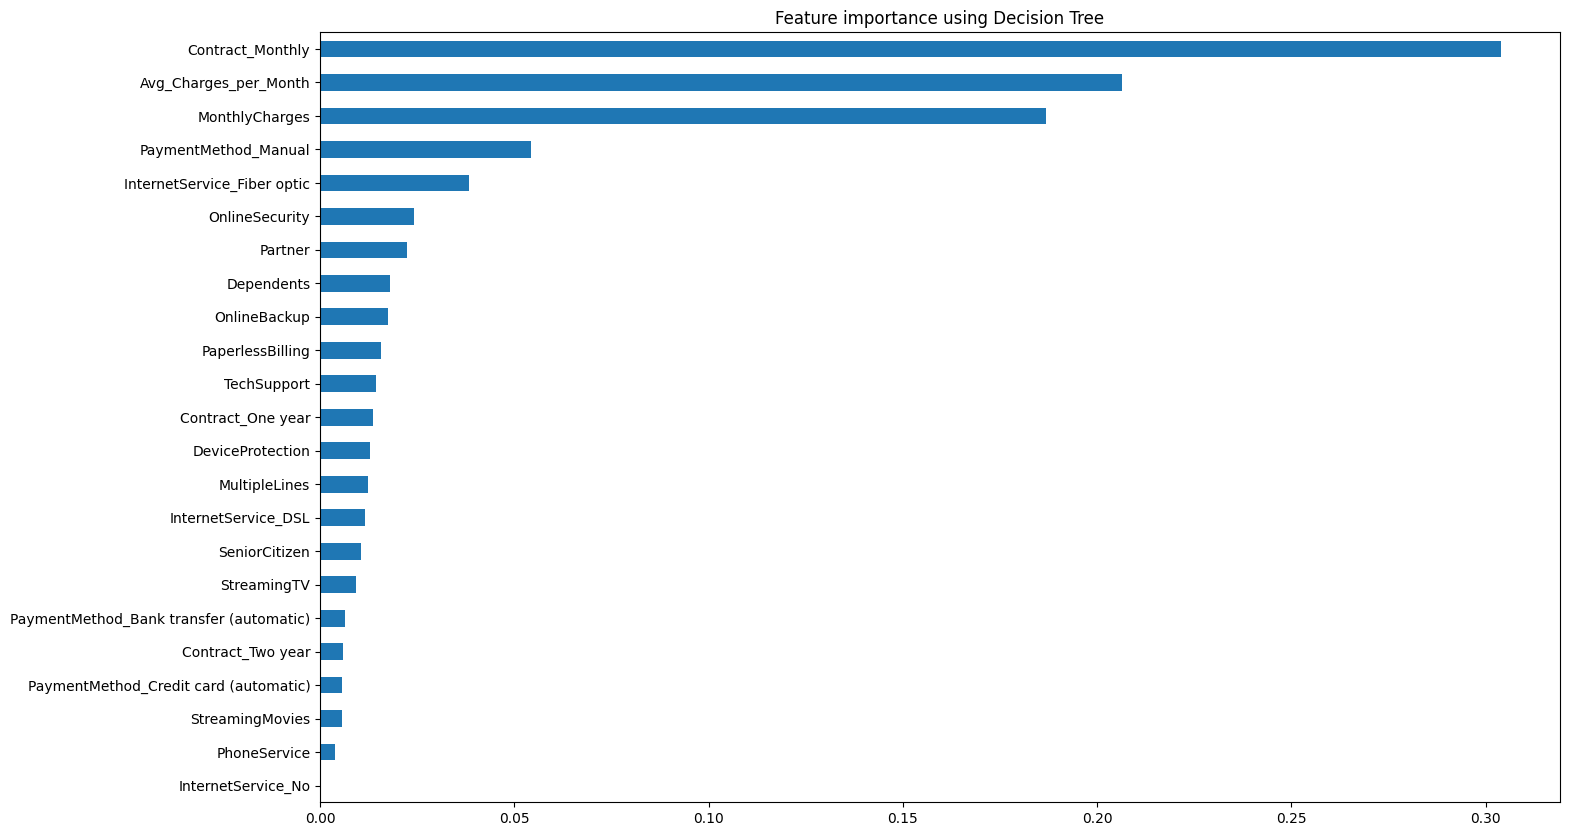

In [110]:
# features coefficient
dt_coef = pd.Series(dt.feature_importances_, index = X_train_smote.columns)
dt_coef_sorted = dt_coef.sort_values()

# plot importance
dt_coef_sorted.plot(kind = "barh")
plt.title("Feature importance using Decision Tree")

In [111]:
# learning curve model

def draw_learning_curve_dt(param_values, X, y, X1, y1):
  train_scores = []
  test_scores = []

  for i in param_values:
    model = DecisionTreeClassifier(max_depth = i, min_samples_split = 100, min_samples_leaf = 30)
    model.fit(X, y)

    # prediction (0/1)
    y_pred_train = model.predict(X)
    y_pred = model.predict(X1)

    # eval on train
    y_pred_train_proba = model.predict_proba(X)
    train_auc = roc_auc_score(y, y_pred_train_proba[:,1])
    train_scores.append(train_auc)

    # eval on test
    y_pred_proba = model.predict_proba(X1)
    test_auc = roc_auc_score(y1, y_pred_proba[:,1])
    test_scores.append(test_auc)

    print('param value: ' + str(i) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc) + '; div: '+ str(train_auc - test_auc) +
          '; train: ' + str(recall_score(y, y_pred_train)) + '; test: '+ str(recall_score(y1, y_pred)) + '; div: '+ str(recall_score(y, y_pred_train) - recall_score(y1, y_pred)))

  plt.plot(param_values, train_scores, label='Train')
  plt.plot(param_values, test_scores, label='Test')
  plt.legend()
  plt.show()

param value: 1; train: 0.7511756569847856; test: 0.5; div: 0.2511756569847856; train: 0.9278008298755187; test: 1.0; div: -0.0721991701244813
param value: 2; train: 0.8118391365315489; test: 0.5; div: 0.31183913653154893; train: 0.9278008298755187; test: 1.0; div: -0.0721991701244813
param value: 3; train: 0.8378612244585627; test: 0.5; div: 0.3378612244585627; train: 0.8910096818810512; test: 1.0; div: -0.10899031811894877
param value: 4; train: 0.8569050119660475; test: 0.5833026509572902; div: 0.27360236100875734; train: 0.8910096818810512; test: 1.0; div: -0.10899031811894877
param value: 5; train: 0.8691469193406143; test: 0.6157722754050073; div: 0.25337464393560694; train: 0.8672199170124482; test: 0.9107142857142857; div: -0.04349436870183754
param value: 6; train: 0.8819840873569287; test: 0.5895066273932255; div: 0.2924774599637032; train: 0.8354080221300139; test: 0.9392857142857143; div: -0.10387769215570042
param value: 7; train: 0.8913798163101723; test: 0.588871502209131

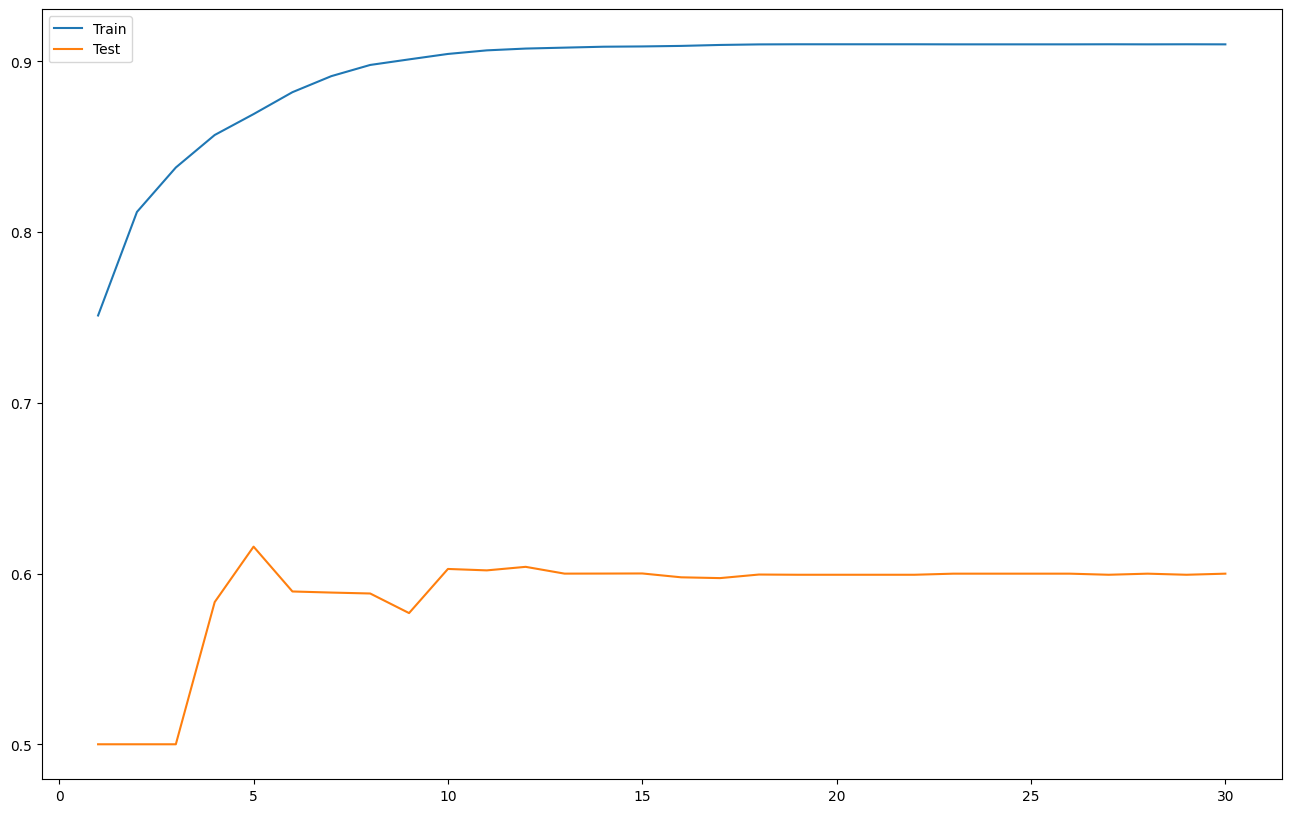

In [112]:
param_values = [int(x) for x in np.linspace(1, 30, num = 30)] # max_depth
# param_values = [int(x) for x in np.linspace(2, 200, num = 50)] # min_samples_split
# param_values = [int(x) for x in np.linspace(10, 110, num = 100)] # min_samples_leaf

draw_learning_curve_dt(param_values, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

In [113]:
# hyperparameter tuning

def dt_tuning(max_depth, min_samples_split, min_samples_leaf,
              max_features, criterion, splitter,
               X, y, X1, y1):

  # hyperparameter
  hyperparameters = dict(max_depth = max_depth,
                         min_samples_split = min_samples_split,
                         min_samples_leaf = min_samples_leaf,
                         max_features = max_features,
                         criterion = criterion,
                         splitter = splitter)

  # import model
  dt = DecisionTreeClassifier(random_state = 123)
  dt_tuned = GridSearchCV(dt, hyperparameters, scoring = 'roc_auc', cv = 5)
  dt_tuned.fit(X, y)

  print('Best max_depth:', dt_tuned.best_estimator_.get_params()['max_depth'])
  print('Best min_samples_split:', dt_tuned.best_estimator_.get_params()['min_samples_split'])
  print('Best min_samples_leaf:', dt_tuned.best_estimator_.get_params()['min_samples_leaf'])
  print('Best max_features:', dt_tuned.best_estimator_.get_params()['max_features'])
  print('Best criterion:', dt_tuned.best_estimator_.get_params()['criterion'])
  print('Best splitter:', dt_tuned.best_estimator_.get_params()['splitter'])

  eval_classification(dt_tuned, X, y, X1, y1)


In [114]:
# list of hyperparameter
max_depth = [10, 11, 12] # Maximum number of levels in tree
min_samples_split = [90, 100, 110] # Minimum number of samples required to split a node
min_samples_leaf = [25, 30, 35] # Minimum number of samples required at each leaf node
max_features = [5, 6, 7] # Number of features to consider at every split
criterion = ['gini', 'entropy']
splitter = ['best', 'random']

dt_tuning(max_depth, min_samples_split, min_samples_leaf,
          max_features, criterion, splitter,
          X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Best max_depth: 11
Best min_samples_split: 90
Best min_samples_leaf: 35
Best max_features: 7
Best criterion: entropy
Best splitter: best
Score:  GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=123),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 11, 12], 'max_features': [5, 6, 7],
                         'min_samples_leaf': [25, 30, 35],
                         'min_samples_split': [90, 100, 110],
                         'splitter': ['best', 'random']},
             scoring='roc_auc')

Accuracy Score(Train set): 0.81
Accuracy Score(Test set): 0.58
Precision Score (Train set):0.79
Precision Score (Test set):0.37
Recall Score (Train set):0.84
Recall Score (Test set):0.84
F1 Score (Train set):0.81
F1 Score (Test set):0.52
ROC AUC Score (Train-proba): 0.89
ROC AUC Score (Test-proba): 0.70


Text(0.5, 1.0, 'Feature importance using Decision Tree')

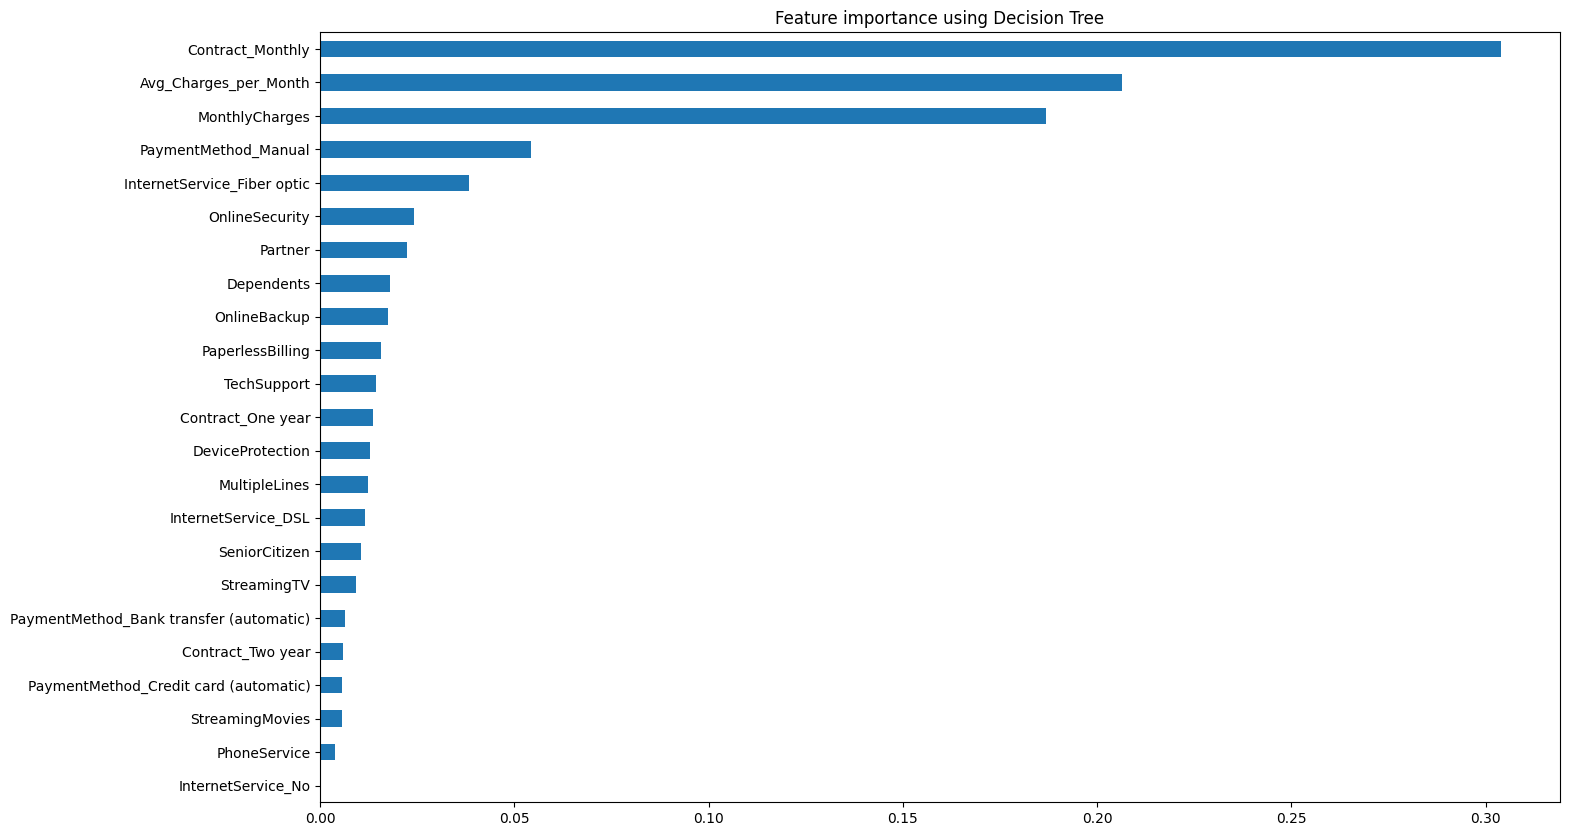

In [115]:
# using best estimator hyperparameter tuning
dt_best = DecisionTreeClassifier(random_state = 123,
                                 max_depth = 11,
                                 min_samples_split = 90,
                                 min_samples_leaf = 35,
                                 max_features = 7,
                                 criterion = 'entropy',
                                 splitter = 'best')

dt_best.fit(X_train_smote, y_train_smote)

# features coefficient
dt_coef = pd.Series(dt.feature_importances_, index = X_train_smote.columns)
dt_coef_sorted = dt_coef.sort_values()

# plot importance
dt_coef_sorted.plot(kind = "barh")
plt.title("Feature importance using Decision Tree")

Hasil feature importance di atas sedikit banyak "mirip" dengan hasil eksplorasi yang dilakukan sebelumnya.

## Random Forest

In [116]:
# import model
rf = RandomForestClassifier(random_state = 123)
rf.fit(X_train_smote, y_train_smote)

# basic model (data train smote)
eval_classification(rf, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  RandomForestClassifier(random_state=123)

Accuracy Score(Train set): 1.00
Accuracy Score(Test set): 0.38
Precision Score (Train set):1.00
Precision Score (Test set):0.27
Recall Score (Train set):1.00
Recall Score (Test set):0.77
F1 Score (Train set):1.00
F1 Score (Test set):0.39
ROC AUC Score (Train-proba): 1.00
ROC AUC Score (Test-proba): 0.56


param value: 1; train: 0.8787190685804691; test: 0.6909264543446245; div: 0.1877926142358446; train: 0.7939142461964038; test: 0.7285714285714285; div: 0.06534281762497529
param value: 2; train: 0.9016987769953455; test: 0.6233362481590574; div: 0.2783625288362881; train: 0.8224066390041493; test: 0.9285714285714286; div: -0.10616478956727926
param value: 3; train: 0.902030574159842; test: 0.7177006627393224; div: 0.18432991142051958; train: 0.8276625172890733; test: 0.875; div: -0.04733748271092675
param value: 4; train: 0.9000964935941951; test: 0.7334660346097202; div: 0.16663045898447493; train: 0.8213001383125864; test: 0.875; div: -0.053699861687413586
param value: 5; train: 0.9047589094922991; test: 0.7277476067746687; div: 0.17701130271763044; train: 0.8434301521438451; test: 0.8464285714285714; div: -0.002998419284726328
param value: 6; train: 0.9063141321793894; test: 0.7036036450662739; div: 0.20271048711311546; train: 0.8232365145228215; test: 0.8928571428571429; div: -0.06

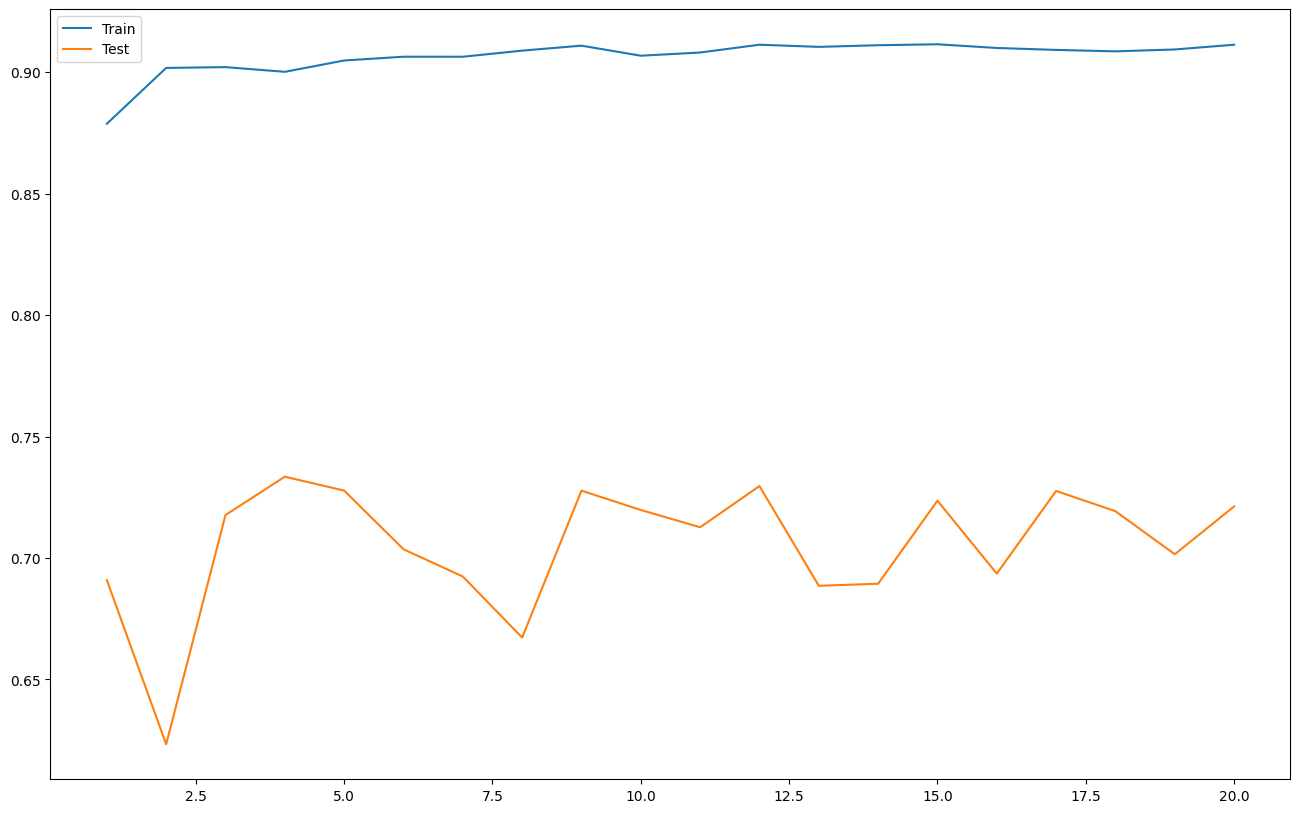

In [117]:
# eksperimen

# parameters values
param_values = [int(x) for x in np.linspace(1, 20, 20)] # n_estimators
# param_values = [int(x) for x in np.linspace(1, 50, 50)] # max_depth
# param_values = [int(x) for x in np.linspace(2, 50, 15)] # min_samples_split
# param_values = [int(x) for x in np.linspace(2, 100, 50)] # min_samples_leaf

train_scores = []
test_scores = []

for i in param_values:
    model = RandomForestClassifier(n_estimators = i, max_depth = 19, min_samples_split = 62, min_samples_leaf = 12)
    model.fit(X_train_smote, y_train_smote)

    # prediction (0/1)
    y_pred_train = model.predict(X_train_smote)
    y_pred = model.predict(X_valid_cleaned)

    # eval on train
    y_pred_train_proba = model.predict_proba(X_train_smote)
    train_auc = roc_auc_score(y_train_smote, y_pred_train_proba[:,1])
    train_scores.append(train_auc)

    # eval on test
    y_pred_proba = model.predict_proba(X_valid_cleaned)
    test_auc = roc_auc_score(y_valid_cleaned, y_pred_proba[:,1])
    test_scores.append(test_auc)

    print('param value: ' + str(i) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc) + '; div: '+ str(train_auc - test_auc) +
          '; train: ' + str(recall_score(y_train_smote, y_pred_train)) + '; test: '+ str(recall_score(y_valid_cleaned, y_pred)) + '; div: '+ str(recall_score(y_train_smote, y_pred_train) - recall_score(y_valid_cleaned, y_pred)))

plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

In [118]:
# tuning hyperparameter RF + oversampling

n_estimators = [7] # Number of trees in random forest
criterion = ['gini', 'entropy'] # Number of criterion to consider at every split
max_depth = [int(x) for x in np.linspace(18, 20, num = 25)] # Maximum number of levels in tree
min_samples_split = [62] # Minimum number of samples required to split a node
min_samples_leaf = [12] # Minimum number of samples required at each leaf node

hyperparameters = dict(n_estimators = n_estimators, criterion = criterion,
                       max_depth = max_depth, min_samples_split = min_samples_split, min_samples_leaf = min_samples_leaf)

In [119]:
rf = RandomForestClassifier(random_state = 123)
rf_tuned = RandomizedSearchCV(rf, hyperparameters, scoring = 'roc_auc', random_state = 123, cv = 5)
rf_tuned.fit(X_train_smote, y_train_smote)

print('Best n_estimators:', rf_tuned.best_estimator_.get_params()['n_estimators'])
print('Best criterion:', rf_tuned.best_estimator_.get_params()['criterion'])
print('Best max_depth:', rf_tuned.best_estimator_.get_params()['max_depth'])
print('Best min_samples_split:', rf_tuned.best_estimator_.get_params()['min_samples_split'])
print('Best min_samples_leaf:', rf_tuned.best_estimator_.get_params()['min_samples_leaf'])

eval_classification(rf_tuned, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Best n_estimators: 7
Best criterion: entropy
Best max_depth: 19
Best min_samples_split: 62
Best min_samples_leaf: 12
Score:  RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=123),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [18, 18, 18, 18, 18, 18,
                                                      18, 18, 18, 18, 18, 18,
                                                      19, 19, 19, 19, 19, 19,
                                                      19, 19, 19, 19, 19, 19,
                                                      20],
                                        'min_samples_leaf': [12],
                                        'min_samples_split': [62],
                                        'n_estimators': [7]},
                   random_state=123, scoring='roc_auc')

Accuracy Score(Train set): 0.82
Accuracy Score(Test set): 0.49
Precision Score (Train set):0.81
Preci

## Adaboost

In [120]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier()
ab.fit(X_train_smote, y_train_smote)
eval_classification(ab,  X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  AdaBoostClassifier()

Accuracy Score(Train set): 0.80
Accuracy Score(Test set): 0.32
Precision Score (Train set):0.78
Precision Score (Test set):0.28
Recall Score (Train set):0.84
Recall Score (Test set):0.98
F1 Score (Train set):0.81
F1 Score (Test set):0.43
ROC AUC Score (Train-proba): 0.89
ROC AUC Score (Test-proba): 0.58


In [121]:
# List of hyperparameter
hyperparameters = dict(n_estimators = [int(x) for x in np.linspace(start = 50, stop = 1000)], # Jumlah iterasi
                       learning_rate = [float(x) for x in np.linspace(start = 0.001, stop = 0.1, num = 200)]
                      )

In [122]:
# Init model
ab = AdaBoostClassifier()
ab_tuned = RandomizedSearchCV(ab, hyperparameters, random_state = 123, cv = 5, scoring = 'roc_auc')
ab_tuned.fit(X_train_smote, y_train_smote)

# Predict & Evaluation
eval_classification(ab_tuned, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(),
                   param_distributions={'learning_rate': [0.001,
                                                          0.0014974874371859296,
                                                          0.0019949748743718593,
                                                          0.002492462311557789,
                                                          0.0029899497487437185,
                                                          0.003487437185929648,
                                                          0.003984924623115577,
                                                          0.0044824120603015076,
                                                          0.004979899497487437,
                                                          0.005477386934673366,
                                                          0.005974874371859296,
                                                          0.006472

## XGBoost

In [123]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train_smote, y_train_smote)
eval_classification(xgb, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

Accuracy Score(Train set): 0.94
Accuracy Score(Test set): 0.27
Precision Score (Train set):0.92
Precision Score (Test set):0.27
Recall Score (Train set):0.96
Recall Score (Test set):1.00
F1 Score (Train set):0.94
F1 Score (Test set):

param value: 1; train: 0.7511756569847856; test: 0.5; div: 0.2511756569847856; train: 0.9278008298755187; test: 1.0; div: -0.0721991701244813
param value: 1; train: 0.7511756569847856; test: 0.5; div: 0.2511756569847856; train: 0.9278008298755187; test: 1.0; div: -0.0721991701244813
param value: 1; train: 0.7511756569847856; test: 0.5; div: 0.2511756569847856; train: 0.9278008298755187; test: 1.0; div: -0.0721991701244813
param value: 2; train: 0.8318405904397881; test: 0.5; div: 0.3318405904397881; train: 0.9278008298755187; test: 1.0; div: -0.0721991701244813
param value: 2; train: 0.8318405904397881; test: 0.5; div: 0.3318405904397881; train: 0.9278008298755187; test: 1.0; div: -0.0721991701244813
param value: 3; train: 0.844262705914537; test: 0.5; div: 0.344262705914537; train: 0.8907330567081605; test: 1.0; div: -0.1092669432918395
param value: 3; train: 0.844262705914537; test: 0.5; div: 0.344262705914537; train: 0.8907330567081605; test: 1.0; div: -0.1092669432918395
param valu

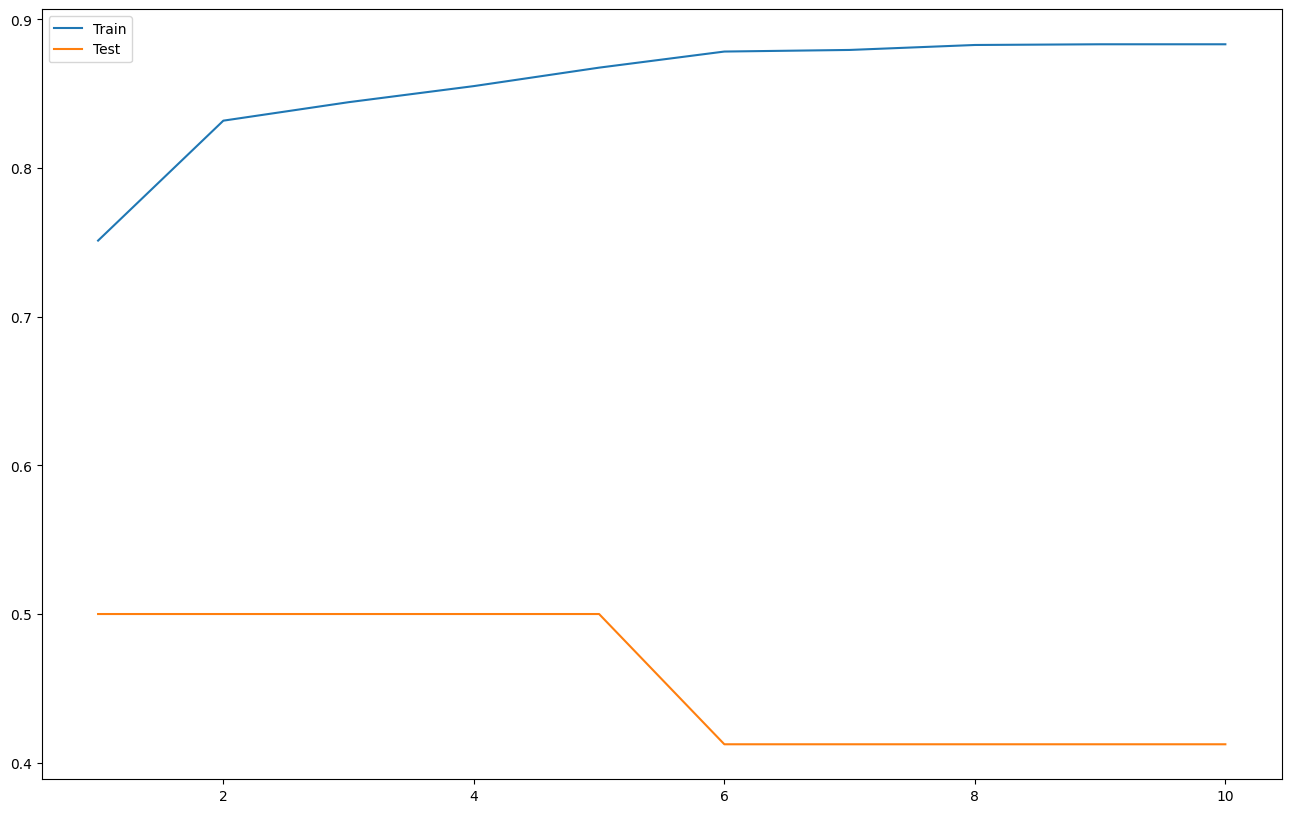

In [124]:
# parameters values
param_values = [int(x) for x in np.linspace(1, 10, num = 20)]     # max_depth; increasing this value will make the model more complex (more likely to overfit)
# param_values = [int(x) for x in np.linspace(1, 50, num = 50)]   # min_child_weight; minimum sum of weights of all observations required in a child [0,~]
# param_values = [float(x) for x in np.linspace(0, 1, num = 15)]    # colsample_bytree
# param_values = [float(x) for x in np.linspace(0, 10, num = 20)]    # gamma; minimum loss reduction required to make a split [0,~] the larger gamma makes model less complex
# param_values = [float(x) for x in np.linspace(0, 1, num = 20)]    # eta; learning rate [0,1]
# param_values = [float(x) for x in np.linspace(0, 1, num = 20)]    # lambda; l2 reg term on weights
# param_values = [float(x) for x in np.linspace(0, 1, num = 20)]    # alpha; l1 reg term on weights

train_scores = []
test_scores = []

for i in param_values:
    model = XGBClassifier(max_depth = i, min_child_weight = 20,
                          gamma = 10, eta = 0.001, reg_lambda = 1, alpha = 0)
    model.fit(X_train_smote, y_train_smote)

    # prediction
    y_pred_train = model.predict(X_train_smote)
    y_pred = model.predict(X_valid_cleaned)

    # eval on train
    y_pred_train_proba = model.predict_proba(X_train_smote)
    train_auc = roc_auc_score(y_train_smote, y_pred_train_proba[:,1])
    train_scores.append(train_auc)

    # eval on test
    y_pred_proba = model.predict_proba(X_valid_cleaned)
    test_auc = roc_auc_score(y_valid_cleaned, y_pred_proba[:,1])
    test_scores.append(test_auc)

    print('param value: ' + str(i) + '; train: ' + str(train_auc) + '; test: '+ str(test_auc) + '; div: '+ str(train_auc - test_auc) +
          '; train: ' + str(recall_score(y_train_smote, y_pred_train)) + '; test: '+ str(recall_score(y_valid_cleaned, y_pred)) + '; div: '+ str(recall_score(y_train_smote, y_pred_train) - recall_score(y_valid_cleaned, y_pred)))

plt.plot(param_values, train_scores, label='Train')
plt.plot(param_values, test_scores, label='Test')
plt.legend()
plt.show()

In [125]:
# hyperparameter

hyperparameters = {
                    'max_depth' : [int(x) for x in np.linspace(10, 20, num = 10)],
                    'min_child_weight' : [int(x) for x in np.linspace(50, 100, num = 50)],
                    'gamma' : [float(x) for x in np.linspace(0, 1, num = 15)],
                    'tree_method' : ['auto', 'exact', 'approx', 'hist'],

                    #'colsample_bytree' : [float(x) for x in np.linspace(0, 1, num = 15)],
                    'eta' : [float(x) for x in np.linspace(0, 1, num = 100)],

                    'lambda' : [float(x) for x in np.linspace(0, 1, num = 15)],
                    'alpha' : [float(x) for x in np.linspace(0, 1, num = 15)]
                    }

In [126]:
xgb = XGBClassifier(random_state = 123)
xgb_tuned = RandomizedSearchCV(xgb, hyperparameters, cv = 5, random_state = 123, scoring = 'roc_auc')
xgb_tuned.fit(X_train_smote, y_train_smote)
eval_classification(xgb_tuned, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Score:  RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                                   0.5714285714285714,
                                                   0.642857

## summary bagian dua

Berdasarkan hasil latih di atas, dengan memperhatikan metrics Recall dan ROC AUC, diperoleh:
- K-nearest neighbor
  - recall: 0.87/0.80
  - ROC-AUC: 0.90/0.79
- Decision Tree
  - recall: 0.84/0.84
  - ROC-AUC: 0.89/0.70
- XGBoost Classifier
  - recall: 0.87/0.85
  - ROC-AUC: 0.95/0.45

Akan diperhatikan model pada KNN Classifier.

# K-Nearest Neighbor Classifier

## Confussion Matrix

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


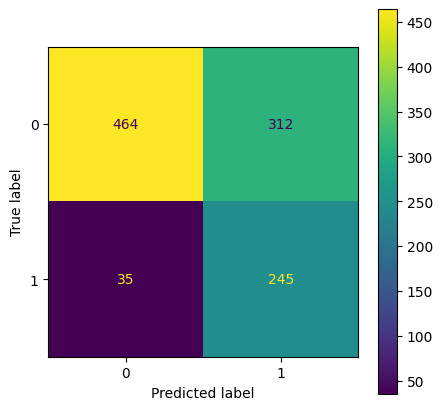


Best n_neighbors: 85
Best p: 2
Best weights: uniform
Best algorithm: auto
Best score: 0.8686493383760994

Score:  RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions={'algorithm': ['auto', 'ball_tree',
                                                      'kd_tree', 'brute'],
                                        'n_neighbors': [85], 'p': [1, 2]},
                   random_state=123, scoring='roc_auc')

Accuracy Score(Train set): 0.78
Accuracy Score(Test set): 0.67
Precision Score (Train set):0.73
Precision Score (Test set):0.44
Recall Score (Train set):0.89
Recall Score (Test set):0.88
F1 Score (Train set):0.80
F1 Score (Test set):0.59
ROC AUC Score (Train-proba): 0.88
ROC AUC Score (Test-proba): 0.80


In [127]:
# model yang dipilih

# hyperparameter
n_neighbors = [85]                                    # sqrt dari len(X)
p = [1, 2]
algorithm = ['auto', 'ball_tree', 'kd_tree', 'brute']

hyperparameters = dict(n_neighbors = n_neighbors,
                       p = p,
                       algorithm = algorithm)

# import model
knn = KNeighborsClassifier()
knn_tuned = RandomizedSearchCV(knn, hyperparameters, scoring = 'roc_auc', random_state = 123, cv = 5)
knn_tuned.fit(X_train_smote, y_train_smote)

# confusion matrix
rcParams["figure.figsize"] = 5, 5
predictions = knn_tuned.predict(X_valid_cleaned)
cm = confusion_matrix(y_valid_cleaned, predictions, labels = knn_tuned.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = knn_tuned.classes_)
disp.plot()
plt.show()

print("")
print('Best n_neighbors:', knn_tuned.best_estimator_.get_params()['n_neighbors'])
print('Best p:', knn_tuned.best_estimator_.get_params()['p'])
print('Best weights:', knn_tuned.best_estimator_.get_params()['weights'])
print('Best algorithm:', knn_tuned.best_estimator_.get_params()['algorithm'])
print('Best score:', knn_tuned.best_score_)
print("")

eval_classification(knn_tuned, X_train_smote, y_train_smote, X_valid_cleaned, y_valid_cleaned)

Diperoleh score:
- Recall: 0.89/0.88
- ROC-AUC: 0.88/0.80

## Test Prediction

In [128]:
# score
eval_classification(knn_tuned, X_train_smote, y_train_smote, X_test_cleaned, y_test_cleaned)

Score:  RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions={'algorithm': ['auto', 'ball_tree',
                                                      'kd_tree', 'brute'],
                                        'n_neighbors': [85], 'p': [1, 2]},
                   random_state=123, scoring='roc_auc')

Accuracy Score(Train set): 0.78
Accuracy Score(Test set): 0.66
Precision Score (Train set):0.73
Precision Score (Test set):0.43
Recall Score (Train set):0.89
Recall Score (Test set):0.84
F1 Score (Train set):0.80
F1 Score (Test set):0.57
ROC AUC Score (Train-proba): 0.88
ROC AUC Score (Test-proba): 0.80


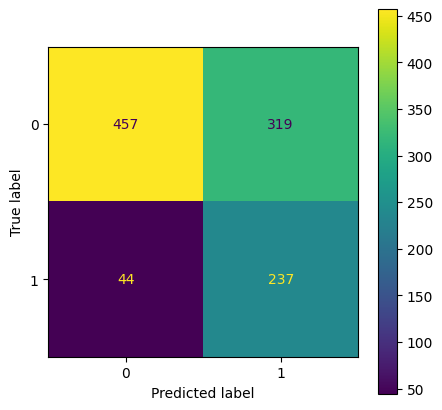

In [129]:
# confusion matrix
rcParams["figure.figsize"] = 5, 5
predictions = knn_tuned.predict(X_test_cleaned)
cm = confusion_matrix(y_test_cleaned, predictions, labels = knn_tuned.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = knn_tuned.classes_)
disp.plot()
plt.show()

# Summary

- Pada model ini, akan dibangun model machine learning untuk memprediksi apakah customer akan berhenti berlangganan atau tidak (customer churn).
- Akan diperhatikan metrics Recall (meminimalisir adanya kesalahan dalam mengabaikan customer yang berhenti berlangganan) dan ROC AUC.
- Dipilih model K-Nearest Neighbor yang memberikan score recall dan ROC AUC yang cukup baik, pada saat dilatih di data training dan data validation.
- Berdasarkan model latih tersebut, didapatkan confussion matrix dengan:
  - 44 customer diprediksi tidak akan berhenti berlangganan, padahal kenyataannya berhenti berlangganan >> terdapat kemungkinan loss 4%.
  - 319 customer diprediksi akan berhenti berlangganan, padahal kenyataannya tidak akan berhenti berlangganan >> terdapat "usaha yang kurang tepat sasaran" 30%.
- Dikarenakan model berfokus pada penurunan persentase customer churn, maka dipilih model yang menghasilkan kemungkinan loss terendah (4%).
- Sebagai implementasi model, dapat dibuat:
  - customer segmentation. melihat karakteristik customer tersebut dan memberikan "pengaruh" agar customer tidak berhenti berlangganan >> pada hasil EDA, didapatkan bahwa service yang berpengaruh terhadap customer churn adalah:
    - Penggunaan InternetService DSL
    - Penggunaan layanan OnlineSecurity, OnlineBackup, dan TechSupport
    - Tidak menggunakan layanan StreamingMovies dan StreamingTV
    - Memberikan promo untuk mengurangi MonthlyCharges untuk paket One year Contract